# Loading necessary libraries

In [1]:
import numpy as np
import pickle
import pandas as pd
from scipy.stats import randint
from pandas.plotting import scatter_matrix
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sb
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [2]:
%matplotlib inline 
rcParams['figure.figsize'] = 5,4
sb.set_style('whitegrid')

# Loading the dataset

In [3]:
df_init = pd.read_csv("bank-full.csv")

In [4]:
df_init.head()

,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
0,"58;""management"";""married"";""tertiary"";""no"";2143..."
1,"44;""technician"";""single"";""secondary"";""no"";29;""..."
2,"33;""entrepreneur"";""married"";""secondary"";""no"";2..."
3,"47;""blue-collar"";""married"";""unknown"";""no"";1506..."
4,"33;""unknown"";""single"";""unknown"";""no"";1;""no"";""n..."


In [5]:
# Read the CSV file and split by semicolons
file_path = 'bank-full.csv'
data = []
with open(file_path, 'r') as file:
    for line in file:
        split_line = line.strip().split(';')
        data.append(split_line)

# Convert the data into a DataFrame
df_init = pd.DataFrame(data)

# Remove double quotes from data
df_init = df_init.applymap(lambda x: x.replace('"', '') if isinstance(x, str) else x)

#convertin the first row as column name and resetting the index 
df_init.columns = df_init.iloc[0]
df_init = df_init[1:]
df_init = df_init.reset_index(drop=True)

saving the new created df as a CSV

In [6]:
#Saving the df into csv file
#df_init.to_csv('Bank-Full-New.csv', index=False)

In [7]:
#Loading newly created CSV
df = pd.read_csv('Bank-Full-New.csv')

In [8]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
df.shape

(45211, 17)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [11]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [12]:
def unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}')
unique_col_values(df)                

job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital: ['married' 'single' 'divorced']
education: ['tertiary' 'secondary' 'unknown' 'primary']
default: ['no' 'yes']
housing: ['yes' 'no']
loan: ['no' 'yes']
contact: ['unknown' 'cellular' 'telephone']
month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome: ['unknown' 'failure' 'other' 'success']
y: ['no' 'yes']


In [13]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [14]:
#Converting the Object types into numeric fields (integers)
def change_int(df):
    col = ['age','day','duration','campaign','pdays','previous']
    for val in col:
        df[val] = pd.to_numeric(df[val], errors='coerce', downcast='integer')
change_int(df)      

In [15]:
#balance is the only floating point and we have converted it from object dtype to float. 
df['balance'] = pd.to_numeric(df['balance'], errors='coerce', downcast='float')

In [16]:
df.dtypes

age             int8
job           object
marital       object
education     object
default       object
balance      float32
housing       object
loan          object
contact       object
day             int8
month         object
duration       int16
campaign        int8
pdays          int16
previous       int16
poutcome      object
y             object
dtype: object

In [17]:
#rename the churn prediction column to churn
df.rename(columns={'y': 'churn'}, inplace=True)
#dropping the column month
#df.drop('month',axis='columns',inplace=True)

In [18]:
df = pd.get_dummies(data=df, columns = ['marital','contact','job', 'education','poutcome'])

In [19]:
#converting all the yes and no to a one or zero
def convert_cat(df):
    cols = ['default','housing','loan','churn']
    for col in cols:
        df[col].replace({'yes': 1,'no': 0},inplace=True)
        
convert_cat(df)
    

In [20]:
df.head()

,age,default,balance,housing,loan,day,month,duration,campaign,pdays,...,job_unemployed,job_unknown,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143.0,1,0,5,may,261,1,-1,...,0,0,0,0,1,0,0,0,0,1
1,44,0,29.0,1,0,5,may,151,1,-1,...,0,0,0,1,0,0,0,0,0,1
2,33,0,2.0,1,1,5,may,76,1,-1,...,0,0,0,1,0,0,0,0,0,1
3,47,0,1506.0,1,0,5,may,92,1,-1,...,0,0,0,0,0,1,0,0,0,1
4,33,0,1.0,0,0,5,may,198,1,-1,...,0,1,0,0,0,1,0,0,0,1


In [21]:
df.describe()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,job_unemployed,job_unknown,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,...,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,0.018027,1362.275635,0.555838,0.160226,15.806419,258.163080,2.763841,40.197828,0.580323,...,0.028820,0.006370,0.151534,0.513194,0.294198,0.041074,0.108403,0.040698,0.033421,0.817478
std,10.618762,0.133049,3044.793213,0.496878,0.366820,8.322476,257.527812,3.098021,100.128746,2.303441,...,0.167303,0.079559,0.358572,0.499831,0.455687,0.198464,0.310892,0.197592,0.179735,0.386278
min,18.000000,0.000000,-8019.000000,0.000000,0.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,0.000000,72.000000,0.000000,0.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,39.000000,0.000000,448.000000,1.000000,0.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,48.000000,0.000000,1428.000000,1.000000,0.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,95.000000,1.000000,102127.000000,1.000000,1.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Visualisations of the data

In [22]:
df1 = df['churn'].value_counts()
print(df1)

0    39922
1     5289
Name: churn, dtype: int64


Data is looking skewed as expected

(array([39922.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  5289.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

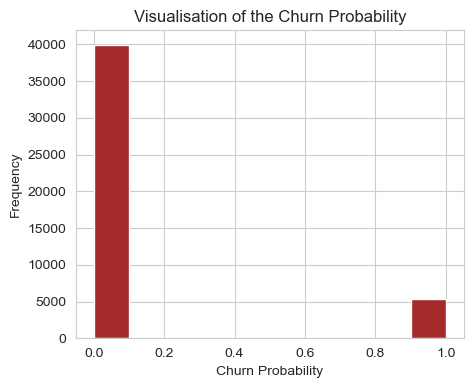

In [23]:
plt.xlabel("Churn Probability")
plt.ylabel("Frequency")
plt.title("Visualisation of the Churn Probability")
plt.hist(df['churn'], color = 'brown')

Let us look at monthly churn and see what the trend looked like

In [24]:
#First let us make our months attribute a categorical variable
df['month'] = pd.Categorical(df['month'], ["jan", "feb", "mar","apr","may","jun","jul","aug","sep","oct","nov","dec"])

In [25]:
df.head(10)

,age,default,balance,housing,loan,day,month,duration,campaign,pdays,...,job_unemployed,job_unknown,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143.0,1,0,5,may,261,1,-1,...,0,0,0,0,1,0,0,0,0,1
1,44,0,29.0,1,0,5,may,151,1,-1,...,0,0,0,1,0,0,0,0,0,1
2,33,0,2.0,1,1,5,may,76,1,-1,...,0,0,0,1,0,0,0,0,0,1
3,47,0,1506.0,1,0,5,may,92,1,-1,...,0,0,0,0,0,1,0,0,0,1
4,33,0,1.0,0,0,5,may,198,1,-1,...,0,1,0,0,0,1,0,0,0,1
5,35,0,231.0,1,0,5,may,139,1,-1,...,0,0,0,0,1,0,0,0,0,1
6,28,0,447.0,1,1,5,may,217,1,-1,...,0,0,0,0,1,0,0,0,0,1
7,42,1,2.0,1,0,5,may,380,1,-1,...,0,0,0,0,1,0,0,0,0,1
8,58,0,121.0,1,0,5,may,50,1,-1,...,0,0,1,0,0,0,0,0,0,1
9,43,0,593.0,1,0,5,may,55,1,-1,...,0,0,0,1,0,0,0,0,0,1


In [26]:
#now let sort all our variables in the months specified 
df2 = df.sort_values("month")

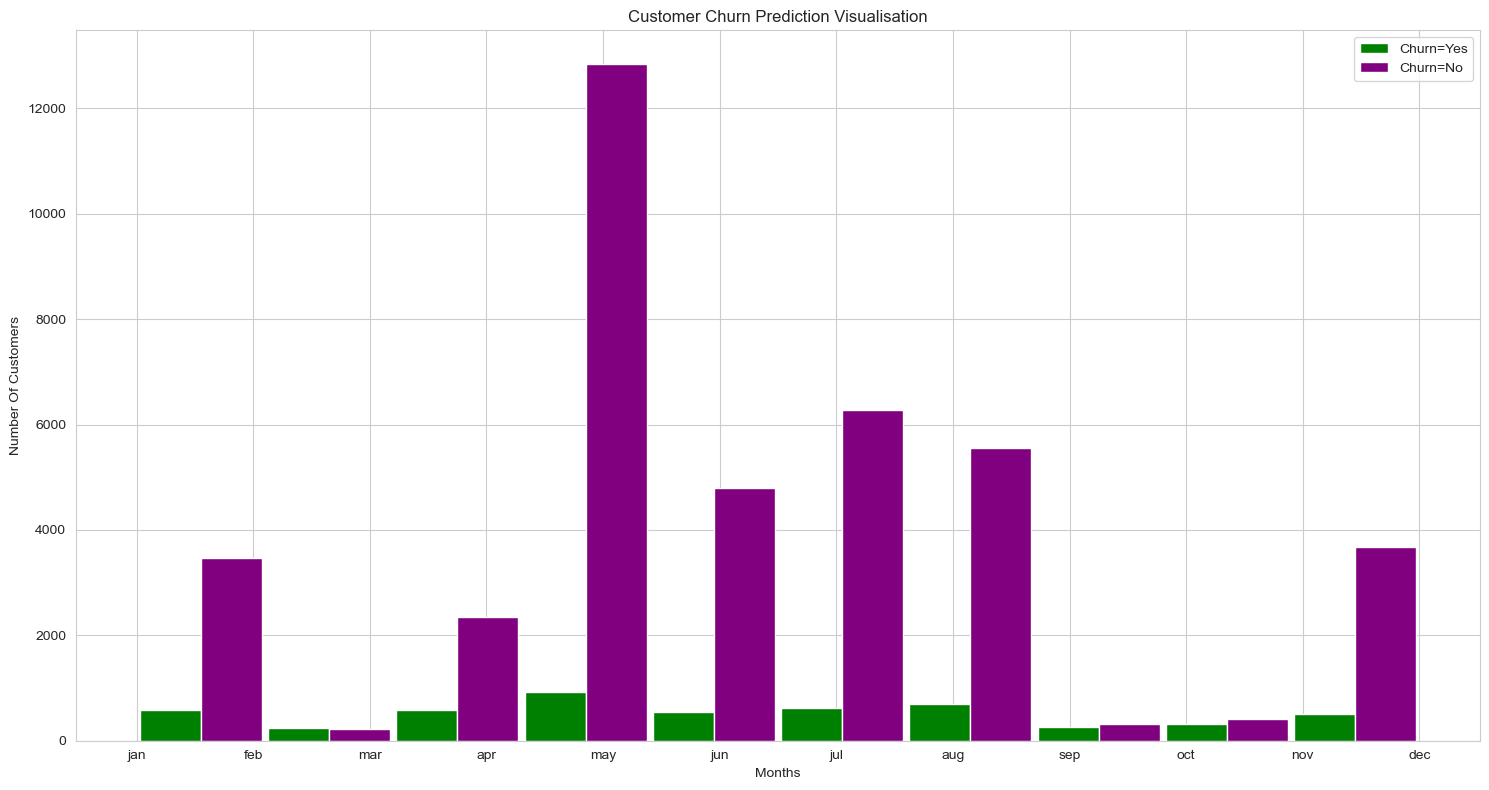

In [27]:
mon_churn_no = df2[df2.churn==0].month
mon_churn_yes = df2[df2.churn==1].month
plt.figure(figsize=(15,8))
plt.xlabel("Months")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualisation")

plt.hist([mon_churn_yes, mon_churn_no], rwidth=0.95, color=['green','purple'],label=['Churn=Yes','Churn=No'])
plt.tight_layout()
plt.legend()

In [28]:
#sb.pairplot(df)

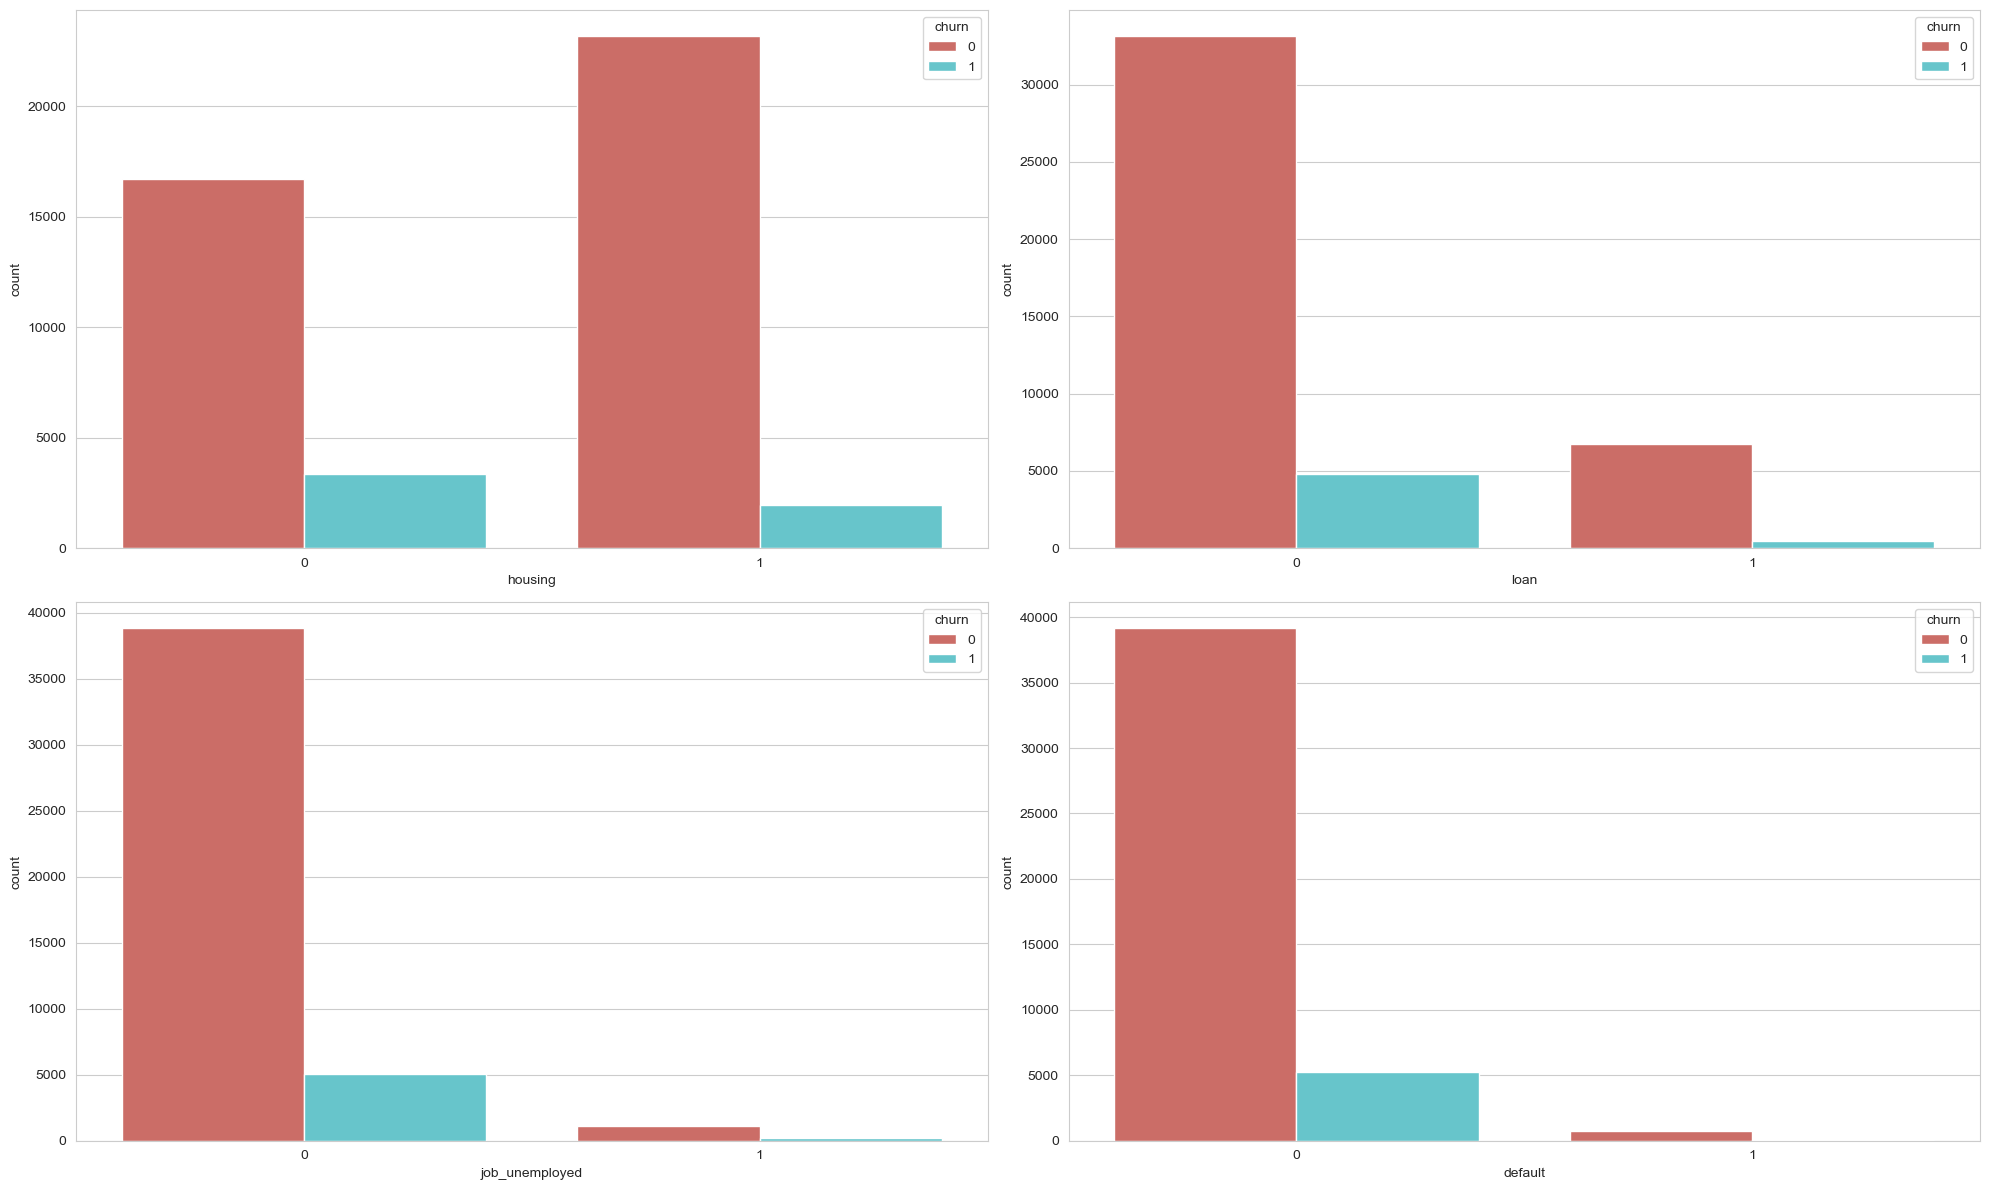

In [29]:
fig, axarr = plt.subplots(2, 2, figsize=(20, 12))
sb.countplot(x='housing', hue = 'churn',data = df, palette='hls',ax=axarr[0][0])
sb.countplot(x='loan', hue = 'churn',data = df, palette='hls', ax=axarr[0][1])
sb.countplot(x='job_unemployed', hue = 'churn',data = df, palette='hls', ax=axarr[1][0])
sb.countplot(x='default', hue = 'churn',data = df, palette='hls', ax=axarr[1][1])
plt.tight_layout()
plt.show();

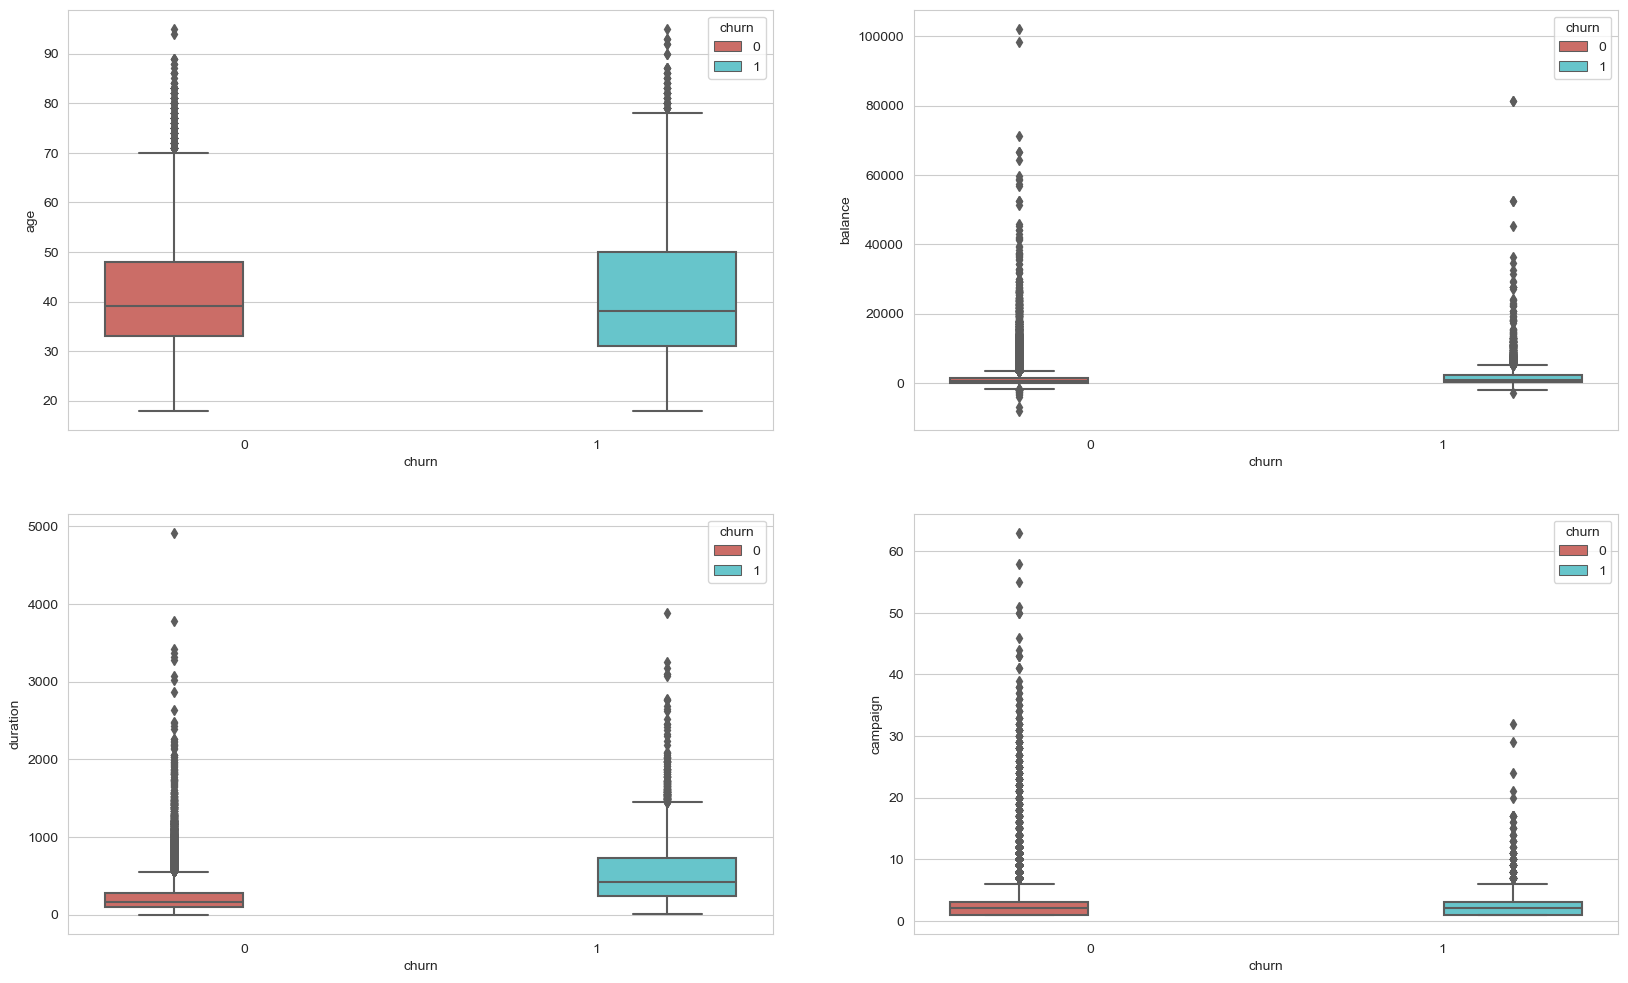

In [30]:
fig, axarr = plt.subplots(2, 2, figsize=(20, 12))
sb.boxplot(y='age',x = 'churn', hue = 'churn',data = df,palette='hls', ax=axarr[0][0])
sb.boxplot(y='balance',x = 'churn', hue = 'churn',data = df , palette='hls', ax=axarr[0][1])
sb.boxplot(y='duration',x = 'churn', hue = 'churn',data = df, palette='hls', ax=axarr[1][0])
sb.boxplot(y='campaign',x = 'churn', hue = 'churn',data = df, palette='hls', ax=axarr[1][1])
plt.show();

<AxesSubplot:>

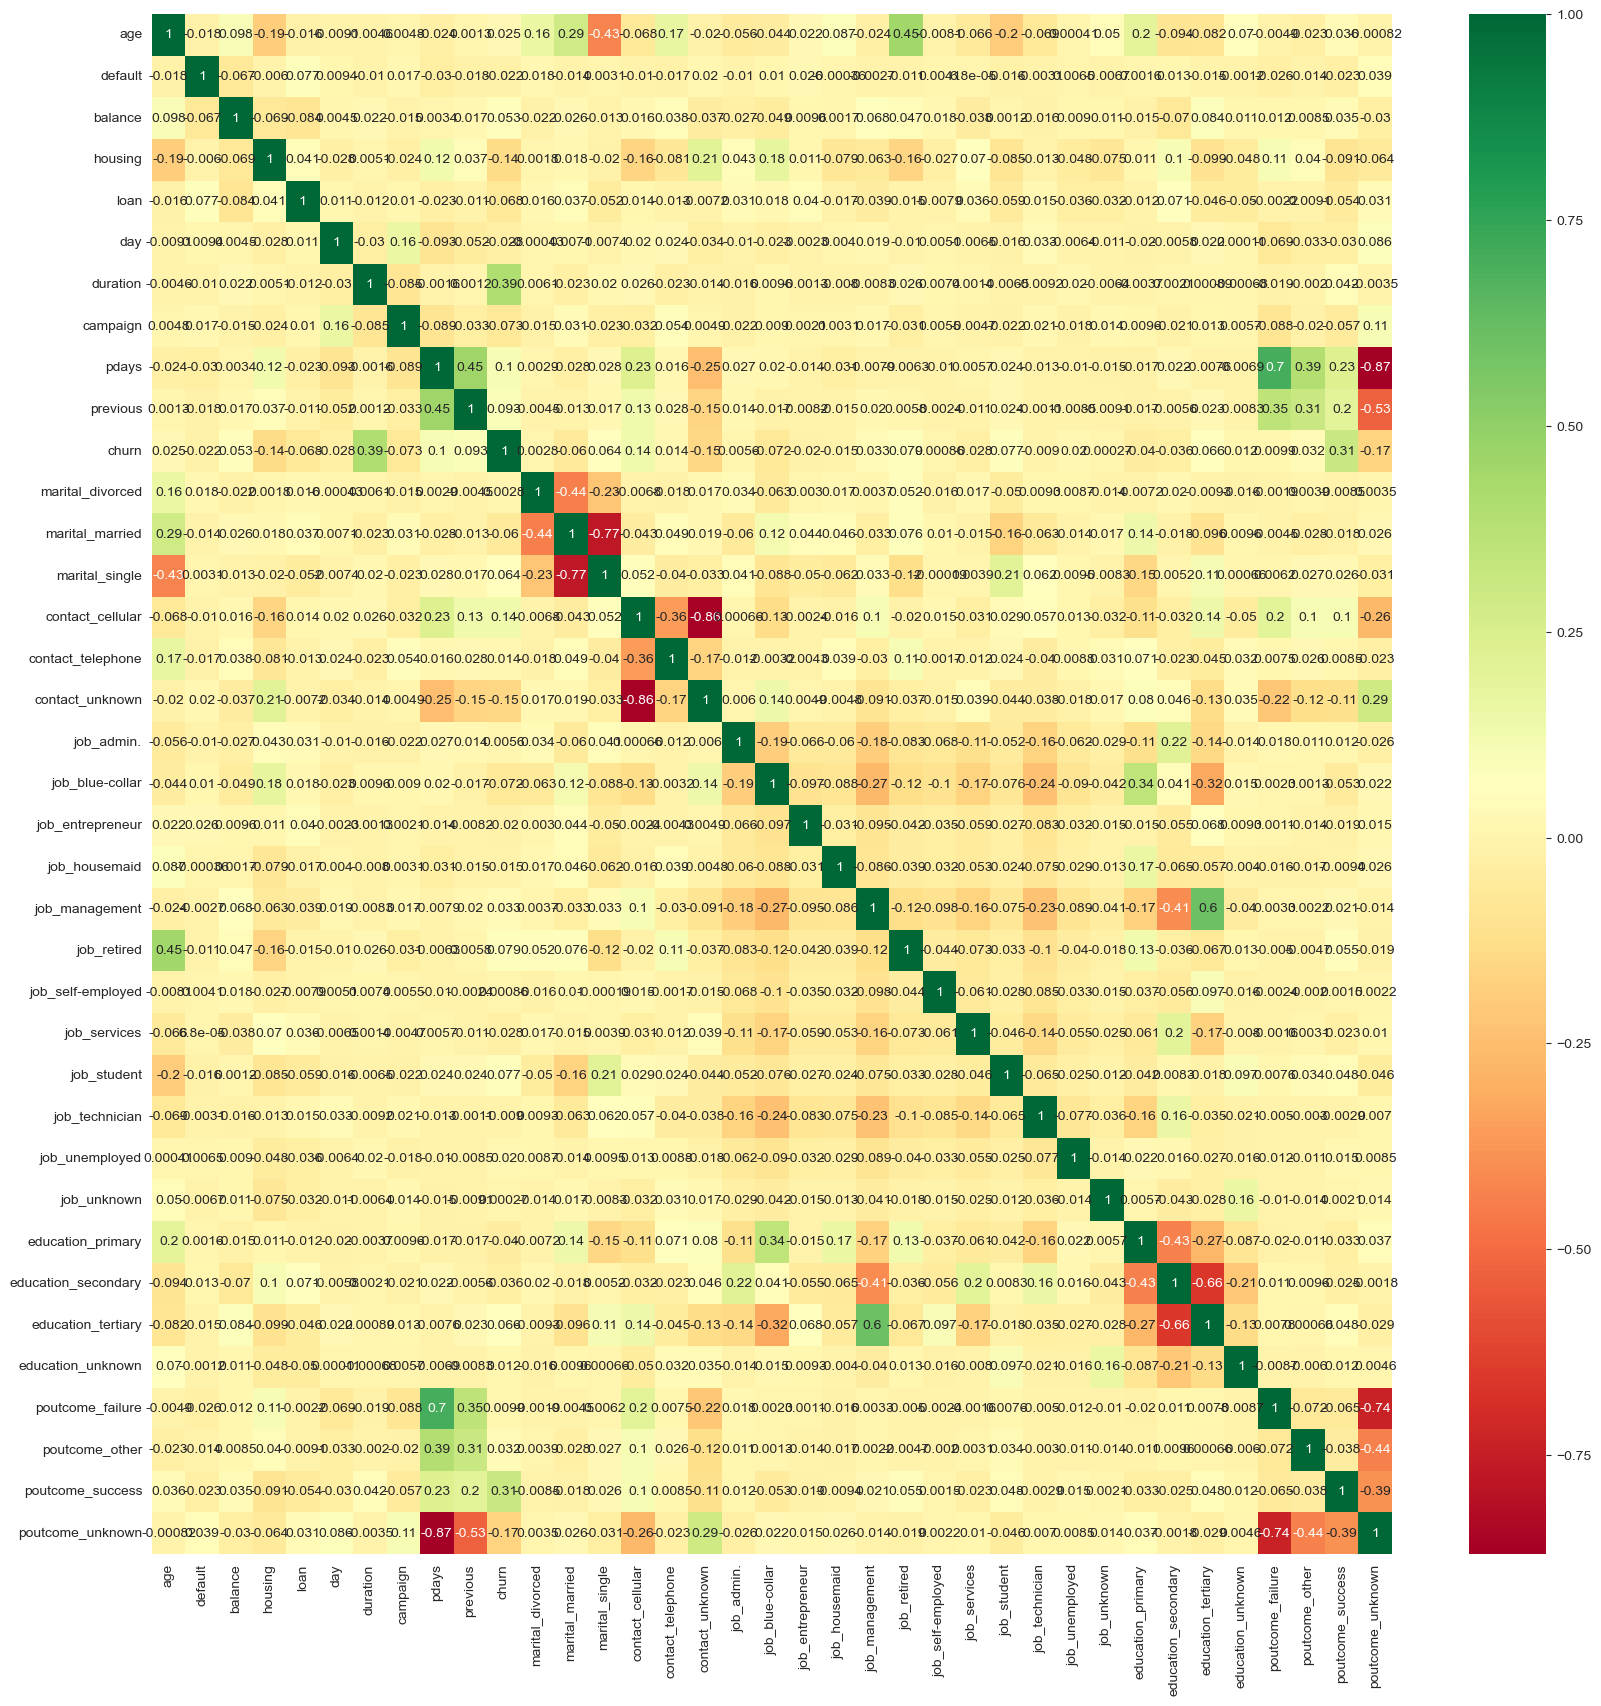

In [31]:
# Plotting The Correlations using a heatmap between all the features
corr_matrix = df.corr()
top_features = corr_matrix.index
plt.figure(figsize=(20,20))
sb.heatmap(df[top_features].corr(), annot=True, cmap='RdYlGn')

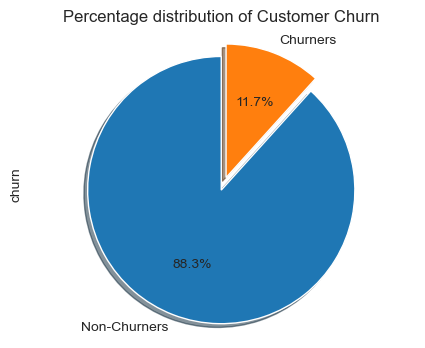

In [32]:
explode = (0, 0.1)
counts = df['churn'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Non-Churners', 'Churners'], explode=explode, startangle=90, shadow=True)
plt.title('Percentage distribution of Customer Churn')
plt.savefig('Bank_pie_chart.png') #saving the plot for use in our documentation
plt.axis('equal')
plt.show()

## Normalising the data using the MinMax Scaler and dropping columns

In [33]:
for col in df:
     print(f'{col}: {df[col].unique()}')

age: [58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
default: [0 1]
balance: [2.1430e+03 2.9000e+01 2.0000e+00 ... 8.2050e+03 1.4204e+04 1.6353e+04]
housing: [1 0]
loan: [0 1]
day: [ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
month: ['may', 'jun', 'jul', 'aug', 'oct', ..., 'jan', 'feb', 'mar', 'apr', 'sep']
Length: 12
Categories (12, object): ['jan', 'feb', 'mar', 'apr', ..., 'sep', 'oct', 'nov', 'dec']
duration: [ 261  151   76 ... 1298 1246 1556]
campaign: [ 1  2  3  5  4  6  7  8  9 10 11 12 13 19 14 24 16 32 18 22 15 17 25 21
 43 51 63 41 26 28 55 50 38 23 20 29 31 37 30 46 27 58 33 35 34 36 39 44]
pdays: [ -1 151 166  91  86 143 147  89 140 176 101 174 170 167 195 165 129 188
 196 172 118 119 104 171 117 164 132 131 123 159 186 111 115 116 173 17

In [34]:
df.dtypes

age                        int8
default                   int64
balance                 float32
housing                   int64
loan                      int64
day                        int8
month                  category
duration                  int16
campaign                   int8
pdays                     int16
previous                  int16
churn                     int64
marital_divorced          uint8
marital_married           uint8
marital_single            uint8
contact_cellular          uint8
contact_telephone         uint8
contact_unknown           uint8
job_admin.                uint8
job_blue-collar           uint8
job_entrepreneur          uint8
job_housemaid             uint8
job_management            uint8
job_retired               uint8
job_self-employed         uint8
job_services              uint8
job_student               uint8
job_technician            uint8
job_unemployed            uint8
job_unknown               uint8
education_primary         uint8
educatio

In [35]:
#scaling the three columns which have values above 1
#df = df.drop('month', axis=1)
scale_cols = ['age','balance','duration','pdays','previous','day','campaign']
scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

#printing the new scaled dataframe
for col in df:
    print(f'{col}: {df[col].unique()}')

age: [0.51948047 0.33766237 0.1948052  0.37662336 0.22077924 0.12987015
 0.31168833 0.32467535 0.29870132 0.14285713 0.45454547 0.50649357
 0.42857143 0.35064933 0.5454545  0.49350652 0.18181819 0.09090909
 0.2857143  0.27272728 0.44155845 0.36363634 0.23376623 0.4025974
 0.5324675  0.24675325 0.41558442 0.4675325  0.4805195  0.38961038
 0.07792208 0.25974026 0.16883117 0.15584415 0.11688313 0.20779222
 0.06493506 0.10389611 0.5584415  0.05194807 0.03896105 0.02597404
 0.6233766  0.57142854 0.8441559  0.74025977 0.6363636  0.6753247
 0.6103896  0.64935064 0.5974026  0.66233766 0.7012987  0.6883117
 0.01298702 0.7532468  0.87012994 0.58441556 0.9350649  0.8311689
 0.71428573 0.72727275 0.7792208  0.80519485 0.987013   0.79220784
 0.7662338  0.88311696 1.         0.8181819  0.         0.922078
 0.8571429  0.896104   0.96103895 0.97402596 0.909091  ]
default: [0 1]
balance: [0.09225936 0.07306666 0.07282153 ... 0.14729542 0.20175949 0.22126997]
housing: [1 0]
loan: [0 1]
day: [0.13333334 

## We have to drop certain features before we can begin the data preparation

In [36]:
df.drop('month',axis='columns',inplace=True)
df.drop('duration',axis='columns',inplace=True)

In [37]:
df.head()

,age,default,balance,housing,loan,day,campaign,pdays,previous,churn,...,job_unemployed,job_unknown,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0.519480,0,0.092259,1,0,0.133333,0.0,0.0,0.0,0,...,0,0,0,0,1,0,0,0,0,1
1,0.337662,0,0.073067,1,0,0.133333,0.0,0.0,0.0,0,...,0,0,0,1,0,0,0,0,0,1
2,0.194805,0,0.072822,1,1,0.133333,0.0,0.0,0.0,0,...,0,0,0,1,0,0,0,0,0,1
3,0.376623,0,0.086476,1,0,0.133333,0.0,0.0,0.0,0,...,0,0,0,0,0,1,0,0,0,1
4,0.194805,0,0.072812,0,0,0.133333,0.0,0.0,0.0,0,...,0,1,0,0,0,1,0,0,0,1


In [38]:
#independent variable - > all the features except the churn column
x = df.drop(['churn'], axis=1)

#dependent variable - > churn column our target variable
y = df['churn']

In [39]:
x.shape

(45211, 35)

In [40]:
y.shape

(45211,)

## Train test Split

In [41]:
#splitting the dataset into training and test data
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state = 42)

In [42]:
X_train.shape

(36168, 35)

In [43]:
y_train.shape

(36168,)

In [44]:
X_test

,age,default,balance,housing,loan,day,campaign,pdays,previous,marital_divorced,...,job_unemployed,job_unknown,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
3776,0.285714,0,0.078069,1,0,0.500000,0.000000,0.000000,0.000000,0,...,0,0,0,1,0,0,0,0,0,1
9928,0.376623,0,0.105887,0,0,0.266667,0.016129,0.000000,0.000000,0,...,0,0,0,1,0,0,0,0,0,1
33409,0.090909,0,0.077688,1,0,0.633333,0.000000,0.000000,0.000000,0,...,0,0,0,0,1,0,0,0,0,1
31885,0.311688,0,0.088900,0,0,0.266667,0.000000,0.386468,0.003636,0,...,0,0,0,0,1,0,1,0,0,0
15738,0.493507,0,0.074773,0,1,0.666667,0.016129,0.000000,0.000000,0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13353,0.376623,0,0.089962,0,0,0.233333,0.000000,0.000000,0.000000,0,...,0,0,0,0,1,0,0,0,0,1
38732,0.181818,0,0.074773,1,0,0.466667,0.032258,0.000000,0.000000,0,...,0,0,0,1,0,0,0,0,0,1
5654,0.441558,0,0.072803,1,0,0.833333,0.000000,0.000000,0.000000,1,...,0,0,0,1,0,0,0,0,0,1
3779,0.285714,0,0.079912,1,1,0.500000,0.016129,0.000000,0.000000,1,...,0,0,0,1,0,0,0,0,0,1


# Applying the resampling techniques to the training data

## Oversampling the training set (SMOTE)

In [45]:
#Apply SMOTE
smt = SMOTE(random_state=42)
x_train_sm, y_train_sm = smt.fit_resample(X_train, y_train)

print('Train data shape: {}'.format(x_train_sm.shape))
print('Test data shape: {}'.format(X_test.shape))
print('Original dataset shape %s' % Counter(y))
print('Resampled dataset shape %s' % Counter(y_train_sm))

Train data shape: (63940, 35)
Test data shape: (9043, 35)
Original dataset shape Counter({0: 39922, 1: 5289})
Resampled dataset shape Counter({0: 31970, 1: 31970})


## Undersampling the data (Random Under Sampler)

In [46]:
#Undersampling our testing and training set
uns = RandomUnderSampler()

x_train_uns, y_train_uns = uns.fit_resample(X_train, y_train)

print('Train data shape: {}'.format(x_train_uns.shape))
print('Test data shape: {}'.format(X_test.shape))
print('Original dataset shape %s' % Counter(y))
print('Resampled dataset shape %s' % Counter(y_train_uns))

Train data shape: (8396, 35)
Test data shape: (9043, 35)
Original dataset shape Counter({0: 39922, 1: 5289})
Resampled dataset shape Counter({0: 4198, 1: 4198})


# SVM Classifier

## Original Dataset with no parameters

In [47]:
 svm = SVC()
svm.fit(X_train, y_train)
y_eval_svm = svm.predict(X_test)

#printing the results
print('Accuracy of SVM training set: {:.2f}'.format(svm.score(X_train, y_train)))
print('Accuracy of SVM test set: {:.2f}'.format(svm.score(X_test, y_test)))
print('\n clasification report:\n', classification_report(y_test,y_eval_svm))
print('\n confussion matrix:\n',confusion_matrix(y_test, y_eval_svm))
print('\n')

Accuracy of SVM training set: 0.89
Accuracy of SVM test set: 0.89

 clasification report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.68      0.19      0.29      1091

    accuracy                           0.89      9043
   macro avg       0.79      0.59      0.62      9043
weighted avg       0.87      0.89      0.86      9043


 confussion matrix:
 [[7855   97]
 [ 889  202]]




## Oversampled  training set

In [64]:
#Model building on balanced dataset
svm.fit(x_train_sm, y_train_sm)
y_eval_svm = svm.predict(X_test)

#printing the results
print('Accuracy of SVM training set: {:.2f}'.format(svm.score(x_train_sm, y_train_sm)))
print('Accuracy of SVM test set: {:.2f}'.format(svm.score(X_test, y_test)))
print('\n clasification report:\n', classification_report(y_test,y_eval_svm))
print('\n confussion matrix:\n',confusion_matrix(y_test, y_eval_svm))
print('\n')

Accuracy of SVM training set: 0.74
Accuracy of SVM test set: 0.73

 clasification report:
               precision    recall  f1-score   support

           0       0.93      0.75      0.83      7952
           1       0.25      0.60      0.35      1091

    accuracy                           0.73      9043
   macro avg       0.59      0.67      0.59      9043
weighted avg       0.85      0.73      0.77      9043


 confussion matrix:
 [[5966 1986]
 [ 439  652]]




## Undersampled training set

In [65]:
#Model building on undersampled dataset
svm.fit(x_train_uns, y_train_uns)
y_eval_svm = svm.predict(X_test)

#printing the results
print('Accuracy of SVM training set: {:.2f}'.format(svm.score(x_train_uns, y_train_uns)))
print('Accuracy of SVM test set: {:.2f}'.format(svm.score(X_test, y_test)))
print('\n clasification report:\n', classification_report(y_test,y_eval_svm))
print('\n confussion matrix:\n',confusion_matrix(y_test, y_eval_svm))
print('\n')

Accuracy of SVM training set: 0.70
Accuracy of SVM test set: 0.70

 clasification report:
               precision    recall  f1-score   support

           0       0.94      0.71      0.81      7952
           1       0.23      0.64      0.34      1091

    accuracy                           0.70      9043
   macro avg       0.58      0.68      0.58      9043
weighted avg       0.85      0.70      0.75      9043


 confussion matrix:
 [[5667 2285]
 [ 393  698]]




# Hyper-Parameter Tuning Using GridSearchCV (SVM)

## SVM imbalanced (original training set)

In [71]:
#The parameter grid for the best paramter and it will be applied on al SVM models as before
parameter_grid = {'C':[.1, 1, 10, 100, 1000], 'gamma':[1,.1, .01, .001, .0001], 'kernel': ['rbf']}

#applying the GridSearchCV on the dictionary of possible or best paramters for us
grid = GridSearchCV(svm, parameter_grid, refit=True, verbose=3)
grid.fit(X_train, y_train)

print('='*40)
print('SVM - Original (Unsampled Dataset)')
print('='*40)

#print the best paramters and best esitimators
print(grid.best_params_)
print(grid.best_estimator_)

#predicting the model and give classification report
y_grid_pred = grid.predict(X_test)
print('\n clasification report:\n', classification_report(y_test,y_grid_pred))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.888 total time= 1.7min
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.890 total time= 1.7min
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.890 total time= 1.7min
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.888 total time= 1.6min
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.887 total time= 1.7min
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.891 total time=  46.1s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.898 total time=  44.7s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.893 total time=  44.2s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.893 total time=  44.1s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.891 total time=  44.4s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.884 total time=  30.1s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

## SVM oversampled training set

In [68]:
#The parameter grid for the best paramter and it will be applied on al SVM models as before
parameter_grid = {'C':[.1, 1, 10, 100, 1000], 'gamma':[1,.1, .01, .001, .0001], 'kernel': ['rbf']}

#applying the GridSearchCV on the dictionary of possible or best paramters for us
grid = GridSearchCV(svm, parameter_grid, refit=True, verbose=3)
grid.fit(x_train_sm, y_train_sm)

print('='*40)
print('SVM - Oversampled Dataset')
print('='*40)

#print the best paramters and best esitimators
print(grid.best_params_)
print(grid.best_estimator_)

#predicting the model and give classification report
y_grid_pred = grid.predict(X_test)
print('\n clasification report:\n', classification_report(y_test,y_grid_pred))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.700 total time=16.1min
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.729 total time= 7.2min
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.727 total time= 7.1min
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.729 total time= 7.2min
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.731 total time= 7.3min
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.682 total time= 5.9min
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.703 total time= 6.2min
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.699 total time= 6.2min
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.704 total time= 6.2min
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.699 total time= 6.2min
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.675 total time= 6.5min
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

## SVM undersampled training set

In [69]:
#The parameter grid for the best paramter and it will be applied on al SVM models as before
parameter_grid = {'C':[.1, 1, 10, 100, 1000], 'gamma':[1,.1, .01, .001, .0001], 'kernel': ['rbf']}

#applying the GridSearchCV on the dictionary of possible or best paramters for us
grid = GridSearchCV(svm, parameter_grid, refit=True, verbose=3)
grid.fit(x_train_uns, y_train_uns)

print('='*40)
print('SVM - Undersampled Dataset')
print('='*40)

#print the best paramters and best esitimators
print(grid.best_params_)
print(grid.best_estimator_)

#predicting the model and give classification report
y_grid_pred = grid.predict(X_test)
print('\n clasification report:\n', classification_report(y_test,y_grid_pred))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.648 total time=   7.2s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.705 total time=   7.4s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.668 total time=   6.9s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.655 total time=   7.7s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.659 total time=   7.2s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.671 total time=   6.6s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.714 total time=   7.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.669 total time=   6.7s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.651 total time=   6.8s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.673 total time=   6.3s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.649 total time=   7.5s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

# Artificial Neural Network (ANN)

## ANN - Unsampled Train Test Split

In [48]:
x.shape

(45211, 35)

ANN - Original Train Test Split (Unsampled Dataset)
283/283 [==============================] - 0s 2ms/step - loss: 0.3261 - accuracy: 0.8863
[0.3260951042175293, 0.8863208889961243]
283/283 [==============================] - 1s 2ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.61      0.16      0.26      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.57      0.60      9043
weighted avg       0.86      0.89      0.86      9043



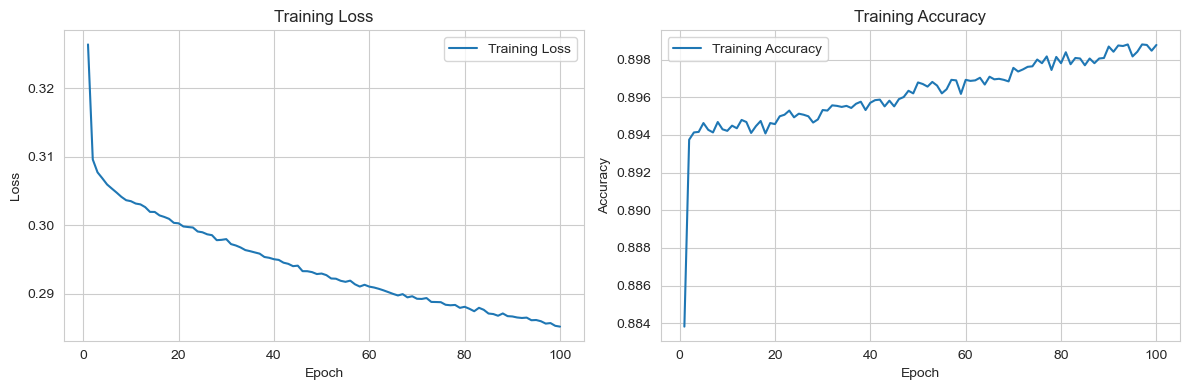

In [49]:
# Artificial Neural network model
model = Sequential()
model.add(Dense(35, input_dim=35, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(X_train, y_train, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Original Train Test Split (Unsampled Dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

Loss:  0.326401948928833 Accuracy:  0.8838199377059937
Loss:  0.3095993101596832 Accuracy:  0.8937458395957947
Loss:  0.3077206015586853 Accuracy:  0.8941329121589661
Loss:  0.30685660243034363 Accuracy:  0.8941605687141418
Loss:  0.305947870016098 Accuracy:  0.8946306109428406
Loss:  0.30534878373146057 Accuracy:  0.894271194934845
Loss:  0.30476269125938416 Accuracy:  0.8941329121589661
Loss:  0.3041423559188843 Accuracy:  0.8946859240531921
Loss:  0.3036497235298157 Accuracy:  0.8942988514900208
Loss:  0.3035053610801697 Accuracy:  0.8942158818244934
Loss:  0.30316227674484253 Accuracy:  0.8944923877716064
Loss:  0.3030409514904022 Accuracy:  0.8943541049957275
Loss:  0.30263617634773254 Accuracy:  0.8947964906692505
Loss:  0.30194446444511414 Accuracy:  0.8946859240531921
Loss:  0.30193257331848145 Accuracy:  0.8941053152084351
Loss:  0.3014298677444458 Accuracy:  0.8944647312164307
Loss:  0.30120551586151123 Accuracy:  0.8947412371635437
Loss:  0.3009262681007385 Accuracy:  0.8940

Text(35.22222222222222, 0.5, 'Actual')

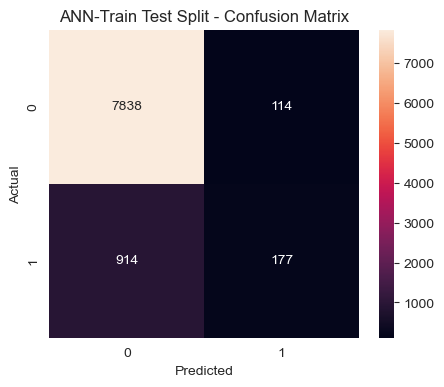

In [52]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## ANN - Oversampled Train Test Split

ANN - Oversampled Train Test Split (resampled Dataset)
283/283 [==============================] - 0s 2ms/step - loss: 0.5084 - accuracy: 0.7733
[0.5084181427955627, 0.7733052968978882]
283/283 [==============================] - 0s 1ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.81      0.86      7952
           1       0.26      0.49      0.34      1091

    accuracy                           0.77      9043
   macro avg       0.59      0.65      0.60      9043
weighted avg       0.84      0.77      0.80      9043



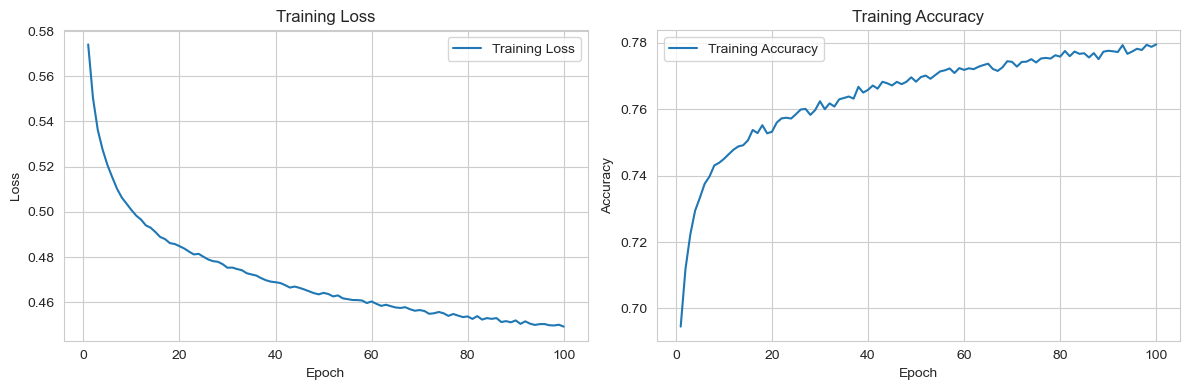

In [53]:
# Artificial Neural network model
model = Sequential()
model.add(Dense(35, input_dim=35, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_sm, y_train_sm, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Oversampled Train Test Split (resampled Dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

Loss:  0.57408207654953 Accuracy:  0.6945261359214783
Loss:  0.5503560900688171 Accuracy:  0.7119174003601074
Loss:  0.5362486839294434 Accuracy:  0.72223961353302
Loss:  0.5275880694389343 Accuracy:  0.7294338345527649
Loss:  0.5208146572113037 Accuracy:  0.7333593964576721
Loss:  0.5153846144676208 Accuracy:  0.7375820875167847
Loss:  0.5102674961090088 Accuracy:  0.7397403717041016
Loss:  0.5063567161560059 Accuracy:  0.7430872917175293
Loss:  0.5036054253578186 Accuracy:  0.7438692450523376
Loss:  0.5008468627929688 Accuracy:  0.7450422048568726
Loss:  0.4983481764793396 Accuracy:  0.7464497685432434
Loss:  0.4966203272342682 Accuracy:  0.747826099395752
Loss:  0.49404987692832947 Accuracy:  0.7488113641738892
Loss:  0.49300193786621094 Accuracy:  0.7491554617881775
Loss:  0.4910847544670105 Accuracy:  0.7506256103515625
Loss:  0.48890358209609985 Accuracy:  0.7537691593170166
Loss:  0.4879728853702545 Accuracy:  0.7528151273727417
Loss:  0.4861993193626404 Accuracy:  0.75519233942

Text(35.22222222222222, 0.5, 'Actual')

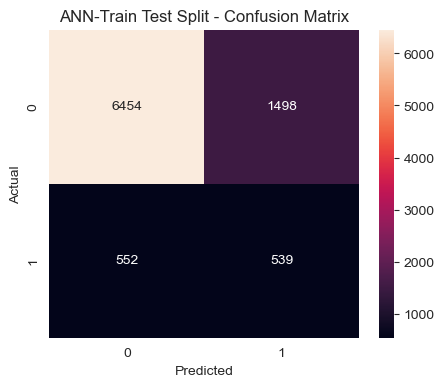

In [54]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## ANN - Undersampled Train Test Split

ANN - Undersampled Train Test Split (Resampled Dataset)
283/283 [==============================] - 1s 3ms/step - loss: 0.7216 - accuracy: 0.6236
[0.7215737104415894, 0.6235762238502502]
283/283 [==============================] - 1s 2ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [1.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.94      0.61      0.74      7952
           1       0.20      0.72      0.32      1091

    accuracy                           0.62      9043
   macro avg       0.57      0.66      0.53      9043
weighted avg       0.85      0.62      0.69      9043



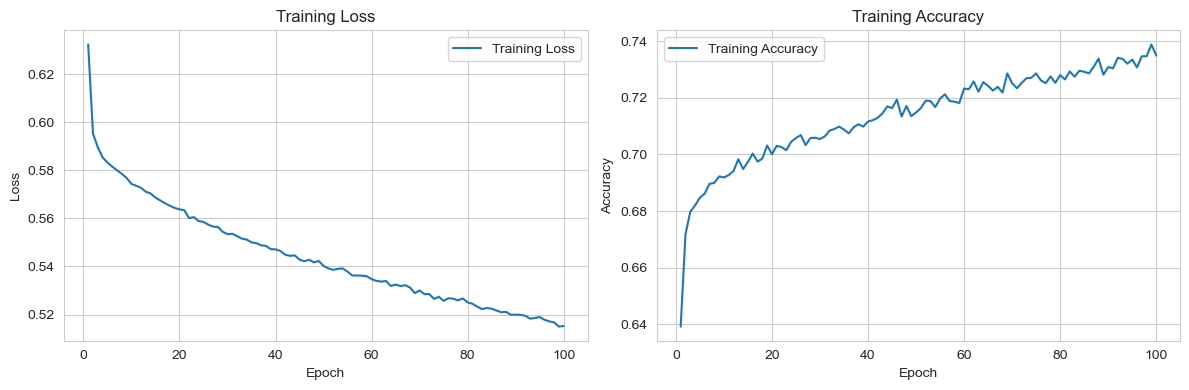

In [55]:
# Artificial Neural network model
model = Sequential()
model.add(Dense(35, input_dim=35, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_uns, y_train_uns, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Undersampled Train Test Split (Resampled Dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

Loss:  0.6323185563087463 Accuracy:  0.6391138434410095
Loss:  0.5952198505401611 Accuracy:  0.6717484593391418
Loss:  0.5895339846611023 Accuracy:  0.6797284483909607
Loss:  0.585370659828186 Accuracy:  0.6819913983345032
Loss:  0.5832224488258362 Accuracy:  0.6847308278083801
Loss:  0.5815190672874451 Accuracy:  0.6861600875854492
Loss:  0.5799654126167297 Accuracy:  0.6896141171455383
Loss:  0.578505277633667 Accuracy:  0.689971387386322
Loss:  0.5767568945884705 Accuracy:  0.6922343969345093
Loss:  0.5743173956871033 Accuracy:  0.6918770670890808
Loss:  0.5735381841659546 Accuracy:  0.692710816860199
Loss:  0.5727068185806274 Accuracy:  0.6941400766372681
Loss:  0.5710603594779968 Accuracy:  0.6983087062835693
Loss:  0.5703436732292175 Accuracy:  0.6948546767234802
Loss:  0.5685972571372986 Accuracy:  0.6973558664321899
Loss:  0.5674583911895752 Accuracy:  0.7003334760665894
Loss:  0.5662553906440735 Accuracy:  0.697475016117096
Loss:  0.5652397274971008 Accuracy:  0.69854694604873

Text(35.22222222222222, 0.5, 'Actual')

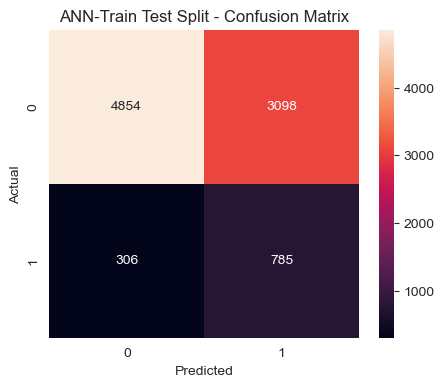

In [56]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# ANN - Hyper-Parameter Tuning

## Model 1 - Adding an extra layer on the model

ANN - Train Test Split
283/283 [==============================] - 1s 2ms/step - loss: 0.5534 - accuracy: 0.7183
[0.5534021854400635, 0.7183457016944885]
283/283 [==============================] - 1s 3ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.74      0.82      7952
           1       0.23      0.57      0.33      1091

    accuracy                           0.72      9043
   macro avg       0.58      0.65      0.58      9043
weighted avg       0.84      0.72      0.76      9043



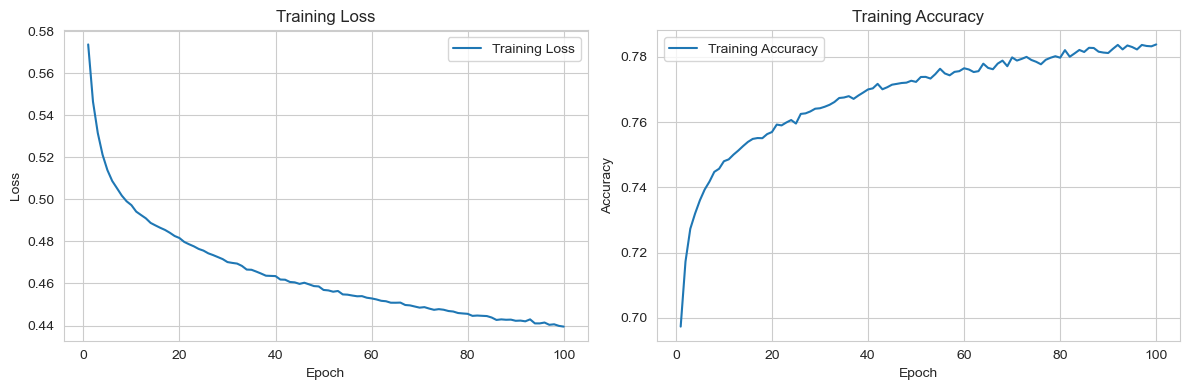

In [58]:
model = Sequential()
model.add(Dense(35, input_dim=35, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_sm, y_train_sm, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Train Test Split')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

Loss:  0.573773205280304 Accuracy:  0.6972943544387817
Loss:  0.5465766787528992 Accuracy:  0.7172192931175232
Loss:  0.5316137075424194 Accuracy:  0.727275550365448
Loss:  0.5212433934211731 Accuracy:  0.7319674491882324
Loss:  0.5139885544776917 Accuracy:  0.7360181212425232
Loss:  0.5088157057762146 Accuracy:  0.7393337488174438
Loss:  0.5053371787071228 Accuracy:  0.7417735457420349
Loss:  0.5018259286880493 Accuracy:  0.7447450757026672
Loss:  0.49911707639694214 Accuracy:  0.7456991076469421
Loss:  0.49730196595191956 Accuracy:  0.7479981184005737
Loss:  0.4942130744457245 Accuracy:  0.748576819896698
Loss:  0.49259865283966064 Accuracy:  0.7500312924385071
Loss:  0.49103161692619324 Accuracy:  0.7512824535369873
Loss:  0.48883485794067383 Accuracy:  0.7526587247848511
Loss:  0.48764488101005554 Accuracy:  0.7539255619049072
Loss:  0.4865138530731201 Accuracy:  0.754848301410675
Loss:  0.4854830205440521 Accuracy:  0.7551141977310181
Loss:  0.4841439127922058 Accuracy:  0.7550672

Text(35.22222222222222, 0.5, 'Actual')

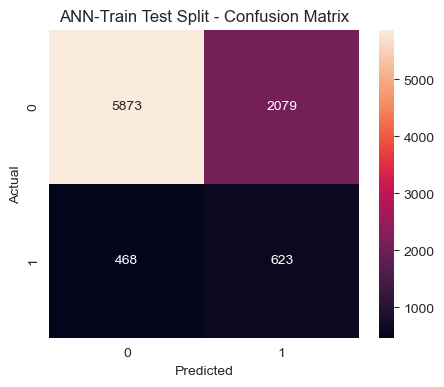

In [60]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Model 2 - Manipulation of the learning rate

ANN - Train Test Split (resampled dataset)
283/283 [==============================] - 1s 2ms/step - loss: 0.5421 - accuracy: 0.7379
[0.5421310663223267, 0.7379188537597656]
283/283 [==============================] - 1s 2ms/step
Accuracy on Test data:  [[1.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.76      0.84      7952
           1       0.24      0.55      0.34      1091

    accuracy                           0.74      9043
   macro avg       0.58      0.66      0.59      9043
weighted avg       0.84      0.74      0.78      9043



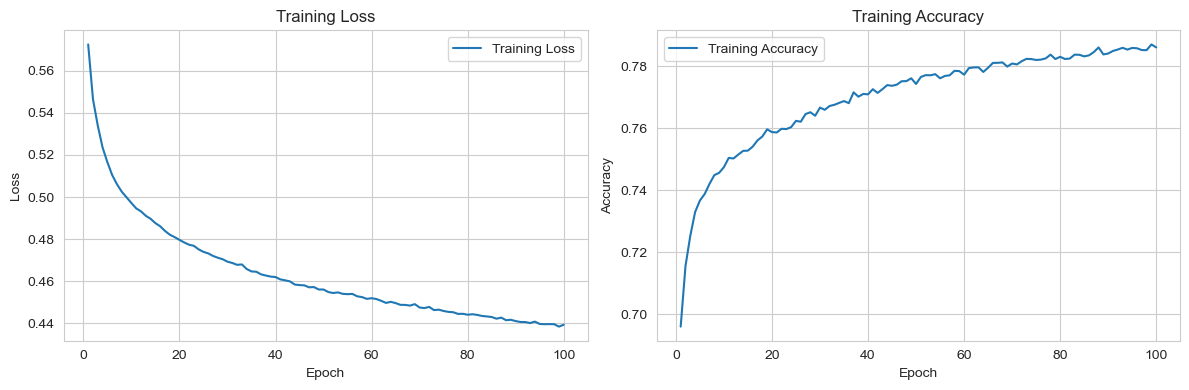

In [61]:
opt_1 = Adam(learning_rate=0.001)

model = Sequential()
model.add(Dense(35, input_dim=35, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=opt_1, loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_sm, y_train_sm, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Train Test Split (resampled dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


Loss:  0.5725969076156616 Accuracy:  0.6959649920463562
Loss:  0.5465272068977356 Accuracy:  0.7154832482337952
Loss:  0.5339568853378296 Accuracy:  0.7252424359321594
Loss:  0.5235481262207031 Accuracy:  0.7328901886940002
Loss:  0.5165384411811829 Accuracy:  0.7366124391555786
Loss:  0.51043301820755 Accuracy:  0.7387394309043884
Loss:  0.5060487985610962 Accuracy:  0.7419924736022949
Loss:  0.5024974346160889 Accuracy:  0.7448076605796814
Loss:  0.49982360005378723 Accuracy:  0.7455583214759827
Loss:  0.4971388280391693 Accuracy:  0.7473881840705872
Loss:  0.49458011984825134 Accuracy:  0.7503597140312195
Loss:  0.49316006898880005 Accuracy:  0.7501876950263977
Loss:  0.49105945229530334 Accuracy:  0.7514544725418091
Loss:  0.48961350321769714 Accuracy:  0.7526274919509888
Loss:  0.4875655174255371 Accuracy:  0.7527213096618652
Loss:  0.48604562878608704 Accuracy:  0.7540193796157837
Loss:  0.4838413894176483 Accuracy:  0.75602126121521
Loss:  0.48206380009651184 Accuracy:  0.757272

Text(35.22222222222222, 0.5, 'Actual')

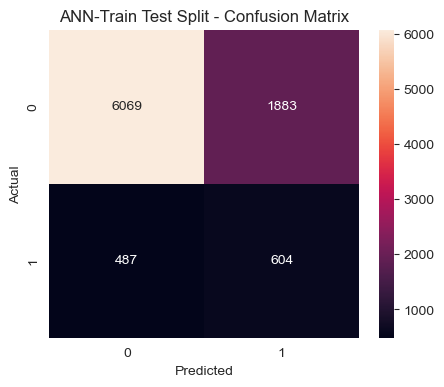

In [62]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Model 3 - Regularisation and dropout

ANN - Train Test Split (resampled dataset)
283/283 [==============================] - 1s 3ms/step - loss: 0.5320 - accuracy: 0.7417
[0.5320488214492798, 0.7416786551475525]
283/283 [==============================] - 1s 2ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [1.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.76      0.84      7952
           1       0.25      0.58      0.35      1091

    accuracy                           0.74      9043
   macro avg       0.59      0.67      0.60      9043
weighted avg       0.85      0.74      0.78      9043



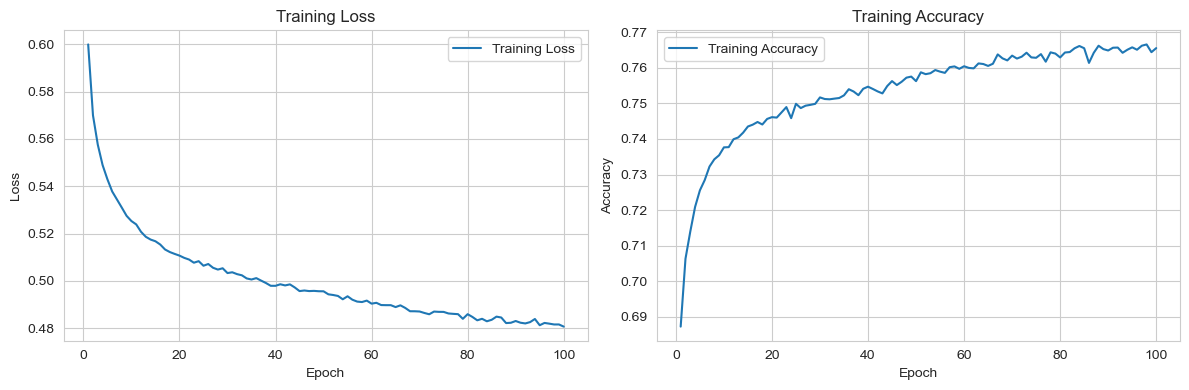

In [63]:
opt_1 = Adam(learning_rate=0.001)

model = Sequential()
model.add(Dense(35, input_dim=35, activation='relu'))
model.add(Dropout(0.05))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.05))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.05))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=opt_1, loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_sm, y_train_sm, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Train Test Split (resampled dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

Loss:  0.5998918414115906 Accuracy:  0.6872536540031433
Loss:  0.5699396133422852 Accuracy:  0.7063340544700623
Loss:  0.5575713515281677 Accuracy:  0.7139818668365479
Loss:  0.5489574074745178 Accuracy:  0.7209102511405945
Loss:  0.5429713726043701 Accuracy:  0.7255551815032959
Loss:  0.5377944111824036 Accuracy:  0.7284328937530518
Loss:  0.5343906879425049 Accuracy:  0.7322489619255066
Loss:  0.5309800505638123 Accuracy:  0.7342821359634399
Loss:  0.5275013446807861 Accuracy:  0.7354238629341125
Loss:  0.5253124833106995 Accuracy:  0.7376446723937988
Loss:  0.5238955020904541 Accuracy:  0.7377071976661682
Loss:  0.5207697749137878 Accuracy:  0.7399280667304993
Loss:  0.5186560750007629 Accuracy:  0.7404441833496094
Loss:  0.5174880027770996 Accuracy:  0.7417735457420349
Loss:  0.5167760252952576 Accuracy:  0.7435095310211182
Loss:  0.5153970122337341 Accuracy:  0.7440256476402283
Loss:  0.5133026242256165 Accuracy:  0.7447763681411743
Loss:  0.5122156739234924 Accuracy:  0.744072556

Text(35.22222222222222, 0.5, 'Actual')

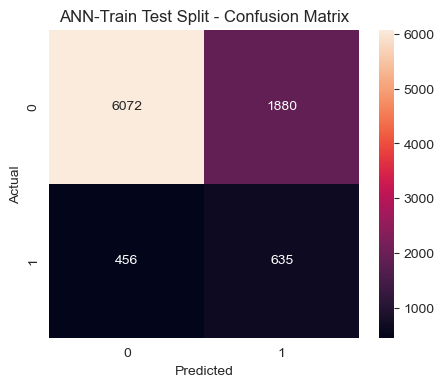

In [64]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Model 4 - Changing the dropout rate 

ANN - Train Test Split (resampled dataset)
283/283 [==============================] - 1s 3ms/step - loss: 0.5506 - accuracy: 0.7376
[0.5506266355514526, 0.7375870943069458]
283/283 [==============================] - 1s 2ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.76      0.84      7952
           1       0.25      0.58      0.35      1091

    accuracy                           0.74      9043
   macro avg       0.59      0.67      0.59      9043
weighted avg       0.85      0.74      0.78      9043



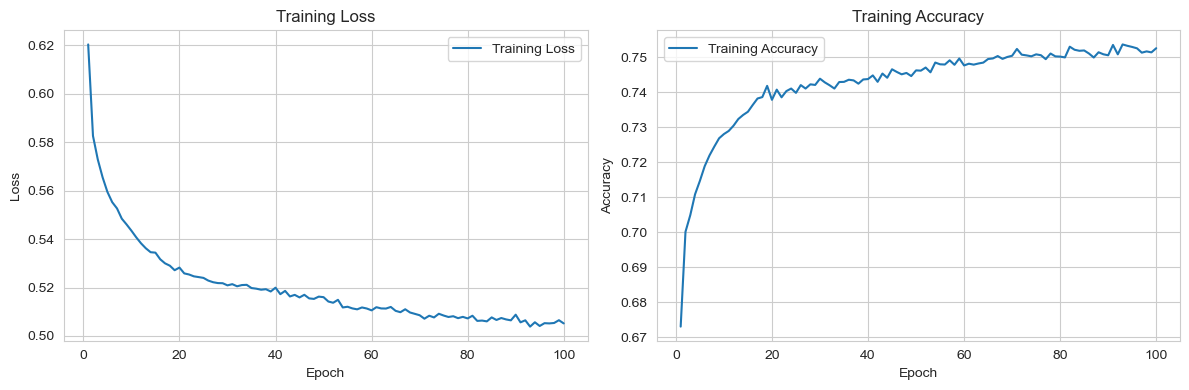

In [66]:
opt_1 = Adam(learning_rate=0.001)

model = Sequential()
model.add(Dense(35, input_dim=35, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=opt_1, loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_sm, y_train_sm, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Train Test Split (resampled dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


Loss:  0.6203970313072205 Accuracy:  0.6729903221130371
Loss:  0.582633912563324 Accuracy:  0.7000938653945923
Loss:  0.5728819370269775 Accuracy:  0.7048639059066772
Loss:  0.5655243992805481 Accuracy:  0.710838258266449
Loss:  0.5595032572746277 Accuracy:  0.7146543860435486
Loss:  0.5552521347999573 Accuracy:  0.718845784664154
Loss:  0.5526692867279053 Accuracy:  0.7219268083572388
Loss:  0.54842209815979 Accuracy:  0.7244448065757751
Loss:  0.5460307002067566 Accuracy:  0.726822018623352
Loss:  0.5434717535972595 Accuracy:  0.728026270866394
Loss:  0.5407350659370422 Accuracy:  0.7289177179336548
Loss:  0.5382562279701233 Accuracy:  0.7304191589355469
Loss:  0.5362002849578857 Accuracy:  0.7323271632194519
Loss:  0.5345796346664429 Accuracy:  0.7334845066070557
Loss:  0.5344054698944092 Accuracy:  0.7344072461128235
Loss:  0.5316624641418457 Accuracy:  0.7363466024398804
Loss:  0.5299819111824036 Accuracy:  0.738192081451416
Loss:  0.5290142893791199 Accuracy:  0.7385987043380737


Text(35.22222222222222, 0.5, 'Actual')

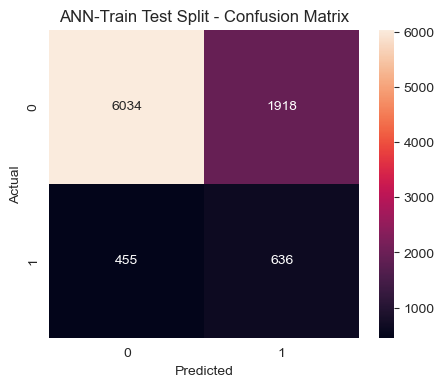

In [67]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

ANN - Train Test Split (resampled dataset)
283/283 [==============================] - 1s 2ms/step - loss: 0.5195 - accuracy: 0.7430
[0.519534170627594, 0.743005633354187]
283/283 [==============================] - 1s 2ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.76      0.84      7952
           1       0.26      0.59      0.36      1091

    accuracy                           0.74      9043
   macro avg       0.59      0.68      0.60      9043
weighted avg       0.85      0.74      0.78      9043



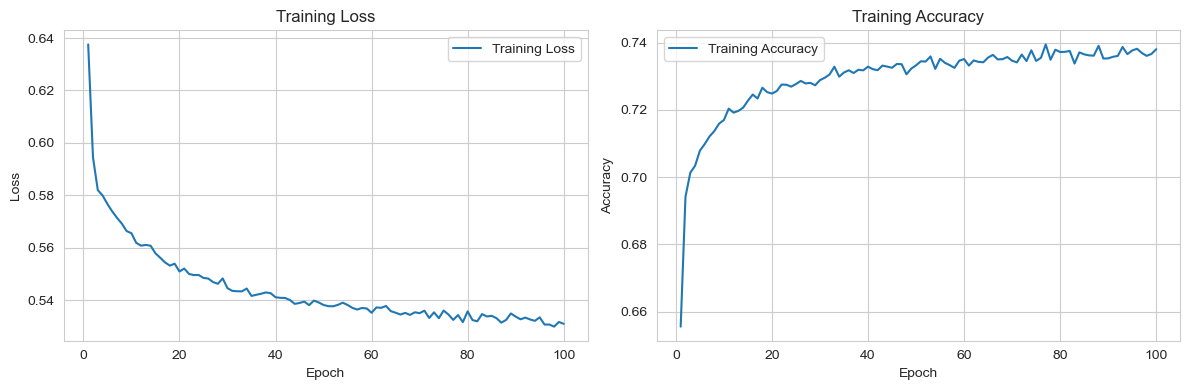

In [68]:
opt_1 = Adam(learning_rate=0.001)

model = Sequential()
model.add(Dense(35, input_dim=35, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=opt_1, loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_sm, y_train_sm, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Train Test Split (resampled dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


Loss:  0.6375609040260315 Accuracy:  0.6555989980697632
Loss:  0.5945069193840027 Accuracy:  0.6941820383071899
Loss:  0.5820019245147705 Accuracy:  0.7012981176376343
Loss:  0.5799486041069031 Accuracy:  0.703393816947937
Loss:  0.5766974687576294 Accuracy:  0.7078667283058167
Loss:  0.5738812685012817 Accuracy:  0.7098217010498047
Loss:  0.5714147090911865 Accuracy:  0.7121050953865051
Loss:  0.5692140460014343 Accuracy:  0.7136846780776978
Loss:  0.5663751363754272 Accuracy:  0.7159055471420288
Loss:  0.5655470490455627 Accuracy:  0.7169846892356873
Loss:  0.5618764162063599 Accuracy:  0.7203628420829773
Loss:  0.5608014464378357 Accuracy:  0.7191742062568665
Loss:  0.5610707998275757 Accuracy:  0.7196747064590454
Loss:  0.5607799291610718 Accuracy:  0.7206443548202515
Loss:  0.5578944087028503 Accuracy:  0.722724437713623
Loss:  0.5561742782592773 Accuracy:  0.7245386242866516
Loss:  0.5544087290763855 Accuracy:  0.7233656644821167
Loss:  0.5531740784645081 Accuracy:  0.72657179832

Text(35.22222222222222, 0.5, 'Actual')

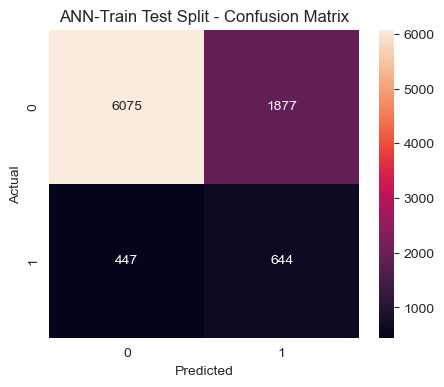

In [69]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Model 5 - Activation Function Change

ANN - Train Test Split (resampled Dataset)
283/283 [==============================] - 2s 8ms/step - loss: 0.4979 - accuracy: 0.8015
[0.49791765213012695, 0.8015038967132568]
283/283 [==============================] - 1s 3ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.84      0.88      7952
           1       0.31      0.51      0.38      1091

    accuracy                           0.80      9043
   macro avg       0.62      0.68      0.63      9043
weighted avg       0.85      0.80      0.82      9043



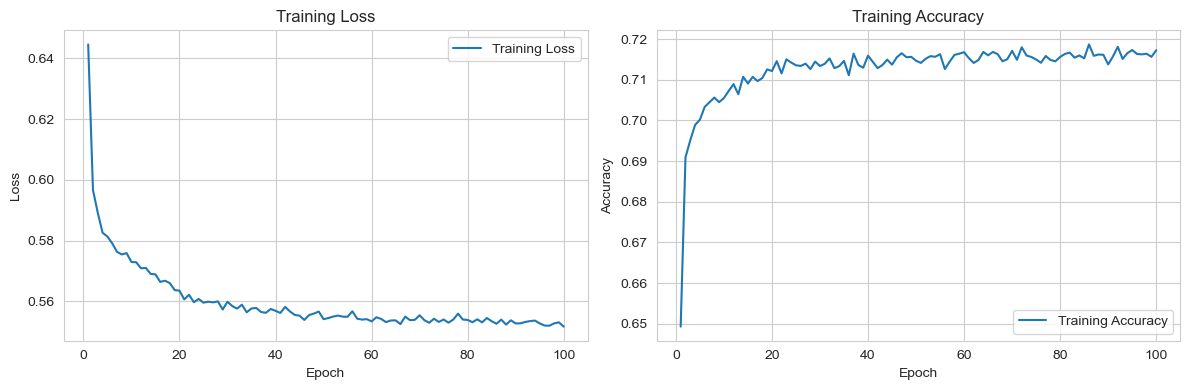

In [70]:
opt_1 = Adam(learning_rate=0.001)

model = Sequential()
model.add(Dense(35, input_dim=35, activation='tanh'))
model.add(Dropout(0.4))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=opt_1, loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_sm, y_train_sm, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Train Test Split (resampled Dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


Loss:  0.6445454359054565 Accuracy:  0.649296224117279
Loss:  0.596616804599762 Accuracy:  0.6909289956092834
Loss:  0.58916175365448 Accuracy:  0.695151686668396
Loss:  0.5825821757316589 Accuracy:  0.6989052295684814
Loss:  0.5813562273979187 Accuracy:  0.7001876831054688
Loss:  0.5791175961494446 Accuracy:  0.7033469080924988
Loss:  0.5763055086135864 Accuracy:  0.7044885754585266
Loss:  0.5754537582397461 Accuracy:  0.7056303024291992
Loss:  0.5758923292160034 Accuracy:  0.7045042514801025
Loss:  0.5729820728302002 Accuracy:  0.7055208086967468
Loss:  0.5728804469108582 Accuracy:  0.707272469997406
Loss:  0.5708997249603271 Accuracy:  0.708930253982544
Loss:  0.5710216760635376 Accuracy:  0.7064591646194458
Loss:  0.5690615177154541 Accuracy:  0.7107601165771484
Loss:  0.5689005851745605 Accuracy:  0.7090866565704346
Loss:  0.5664243698120117 Accuracy:  0.7107444405555725
Loss:  0.5668171644210815 Accuracy:  0.70968097448349
Loss:  0.5660091638565063 Accuracy:  0.7104473114013672
L

Text(35.22222222222222, 0.5, 'Actual')

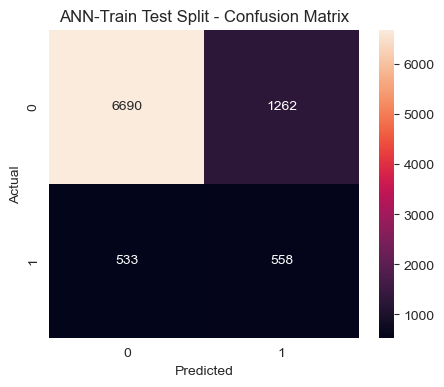

In [71]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Model 6 - Removing an extra layer after addition of the new activation function

ANN - Train Test Split (resampled dataset)
283/283 [==============================] - 1s 3ms/step - loss: 0.5985 - accuracy: 0.7099
[0.5984550714492798, 0.7099413871765137]
283/283 [==============================] - 1s 2ms/step
Accuracy on Test data:  [[0.]
 [0.]
 [1.]
 ...
 [0.]
 [0.]
 [0.]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.72      0.81      7952
           1       0.24      0.63      0.35      1091

    accuracy                           0.71      9043
   macro avg       0.59      0.68      0.58      9043
weighted avg       0.85      0.71      0.76      9043



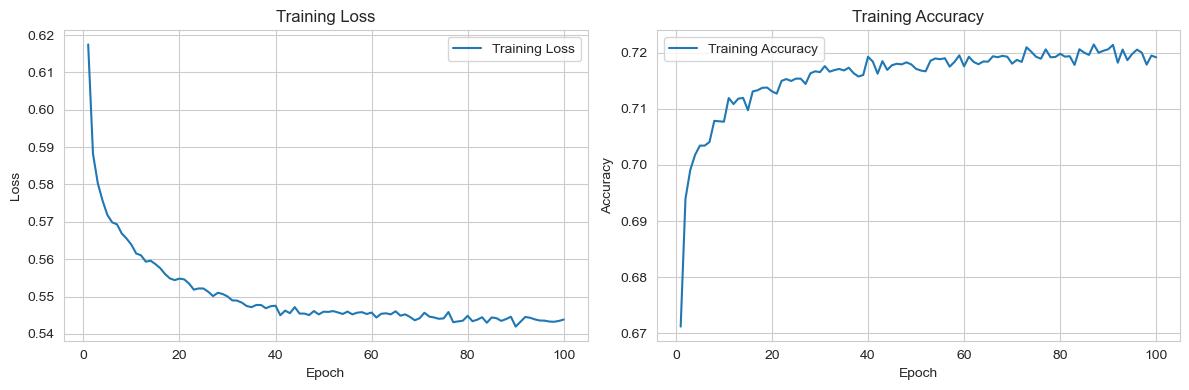

In [72]:
opt_1 = Adam(learning_rate=0.001)

model = Sequential()
model.add(Dense(35, input_dim=35, activation='tanh'))
model.add(Dropout(0.4))
model.add(Dense(15, activation='relu', kernel_regularizer=L2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=opt_1, loss='binary_crossentropy', metrics=['accuracy'])

# Lists to store loss and accuracy values
loss_history = []
accuracy_history = []

# Train the model and record loss and accuracy at each epoch
epochs = 100  
for epoch in range(epochs):
    history = model.fit(x_train_sm, y_train_sm, epochs=1, validation_data=(X_test, y_test), verbose=0)
    
    # Record loss and accuracy
    loss_history.append(history.history['loss'][0])
    accuracy_history.append(history.history['accuracy'][0])

    
print('='*80)
print('ANN - Train Test Split (resampled dataset)')
print('='*80)    

print(model.evaluate(X_test, y_test))    
y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
    
# Plotting the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracy_history, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


Loss:  0.6175042390823364 Accuracy:  0.6712073683738708
Loss:  0.5882313847541809 Accuracy:  0.6939943432807922
Loss:  0.5803501009941101 Accuracy:  0.6991085410118103
Loss:  0.5756521224975586 Accuracy:  0.7017985582351685
Loss:  0.5718351602554321 Accuracy:  0.7034407258033752
Loss:  0.5698530673980713 Accuracy:  0.7034407258033752
Loss:  0.5693256258964539 Accuracy:  0.7040819525718689
Loss:  0.5668648481369019 Accuracy:  0.7078511118888855
Loss:  0.5655103921890259 Accuracy:  0.7077729105949402
Loss:  0.5638664364814758 Accuracy:  0.7076947093009949
Loss:  0.5615139007568359 Accuracy:  0.7119174003601074
Loss:  0.5610361099243164 Accuracy:  0.710838258266449
Loss:  0.5593251585960388 Accuracy:  0.7118079662322998
Loss:  0.5595889687538147 Accuracy:  0.7119330763816833
Loss:  0.5586698055267334 Accuracy:  0.7097434997558594
Loss:  0.5575886964797974 Accuracy:  0.7130904197692871
Loss:  0.5560312271118164 Accuracy:  0.713293731212616
Loss:  0.5548595190048218 Accuracy:  0.71373164653

Text(35.22222222222222, 0.5, 'Actual')

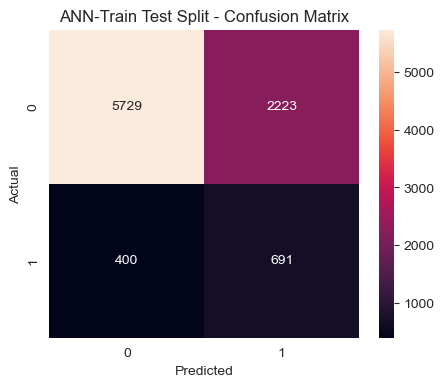

In [73]:
#Printing the Loss and Accuracy
for i, j in zip(loss_history, accuracy_history):
    print('Loss: ',i,'Accuracy: ',j)
print("\n")
#Cofusion Matrix
conf_mat = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN-Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Random Forests Classifier

## RF - Original Train Test Split

Random Forests - Original Train Test Split
Accuracy on Test data:  [0 0 0 ... 0 0 0]
Classification Report: 
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.71      0.17      0.28      1091

    accuracy                           0.89      9043
   macro avg       0.81      0.58      0.61      9043
weighted avg       0.88      0.89      0.86      9043





Text(35.22222222222222, 0.5, 'Actual')

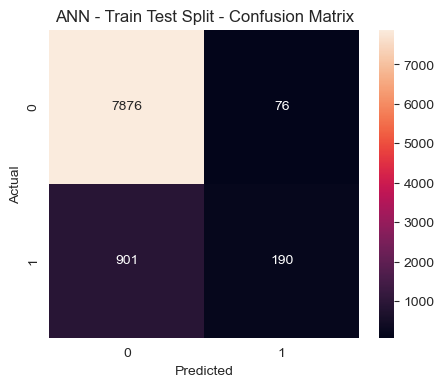

In [74]:
#Buidling the Random Forest Ensemble Model and Training
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth = 10, max_features = 'sqrt')
rf_clf.fit(X_train,y_train)

#Testing the Model
y_pred = rf_clf.predict(X_test)
y_pred = np.round(y_pred)

#printing Classification results and Confusion matrix
print('='*80)
print('Random Forests - Original Train Test Split')
print('='*80) 
print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
print('\n')
conf_mat = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN - Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## RF - Oversampled Train Test Split

Random Forests - Original Train Test Split
Accuracy on Test data:  [0 0 1 ... 0 0 0]
Classification Report: 
               precision    recall  f1-score   support

           0       0.93      0.82      0.87      7952
           1       0.30      0.56      0.39      1091

    accuracy                           0.79      9043
   macro avg       0.62      0.69      0.63      9043
weighted avg       0.86      0.79      0.81      9043





Text(35.22222222222222, 0.5, 'Actual')

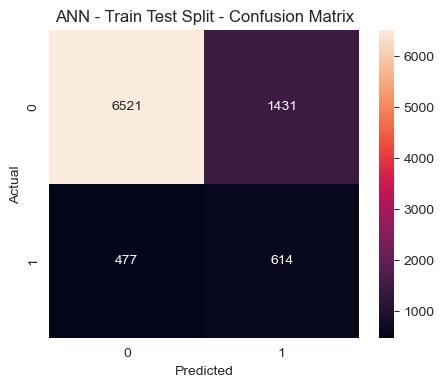

In [75]:
#Buidling the Random Forest Ensemble Model and Training
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth = 10, max_features = 'sqrt')
rf_clf.fit(x_train_sm, y_train_sm)

#Testing the Model
y_pred = rf_clf.predict(X_test)
y_pred = np.round(y_pred)

#printing Classification results and Confusion matrix
print('='*80)
print('Random Forests - Original Train Test Split')
print('='*80) 
print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
print('\n')
conf_mat = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN - Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## RF - Undersampled Train Test Split

Random Forests - Undersampled Train Test Split
Accuracy on Test data:  [0 0 1 ... 0 0 0]
Classification Report: 
               precision    recall  f1-score   support

           0       0.94      0.76      0.84      7952
           1       0.27      0.64      0.38      1091

    accuracy                           0.74      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.74      0.78      9043





Text(35.22222222222222, 0.5, 'Actual')

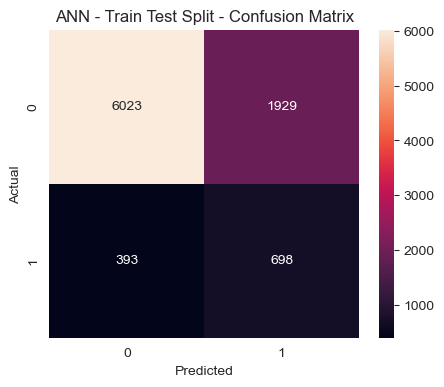

In [77]:
#Buidling the Random Forest Ensemble Model and Training
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth = 10, max_features = 'sqrt')
rf_clf.fit(x_train_uns, y_train_uns)

#Testing the Model
y_pred = rf_clf.predict(X_test)
#y_pred = np.round(y_pred)

#printing Classification results and Confusion matrix
print('='*80)
print('Random Forests - Undersampled Train Test Split')
print('='*80) 
print('Accuracy on Test data: ',y_pred)
print("Classification Report: \n", classification_report(y_test, y_pred))
print('\n')
conf_mat = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN - Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Hyper-Parameter Tuning with RandomSearchCV

## Apply the RandomSearchCV using original 

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Random Search - Best Hyperparameters: 
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}

 clasification report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.71      0.17      0.28      1091

    accuracy                           0.89      9043
   macro avg       0.80      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043





Text(35.22222222222222, 0.5, 'Actual')

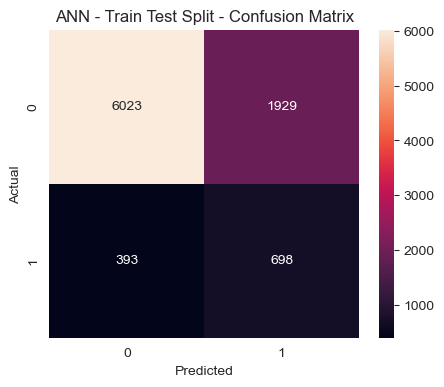

In [78]:
#loading the classifier
rf_clf = RandomForestClassifier(random_state=42)

# Define hyperparameter grids for Randomized Search and Grid Search
param_grid_random = {
    'n_estimators': [int(x) for x in np.linspace(start=200, stop=2000, num=10)],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [int(x) for x in np.linspace(10, 110, num=11)] + [None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Random Search
rand_search = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_grid_random, 
                                   n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
rand_search.fit(X_train, y_train)

# Print the best hyperparameters found by each search method
print("Random Search - Best Hyperparameters: ")
print(rand_search.best_params_)

y_rand_pred = rand_search.predict(X_test)
print('\n clasification report:\n', classification_report(y_test,y_rand_pred))
print("\n")

conf_mat = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN - Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Applying RandomSearchCV on Oversampled Train Test Split

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Random Search - Best Hyperparameters: 
{'n_estimators': 1400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'auto', 'max_depth': 40, 'bootstrap': False}

 clasification report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92      7952
           1       0.41      0.30      0.35      1091

    accuracy                           0.86      9043
   macro avg       0.66      0.62      0.63      9043
weighted avg       0.85      0.86      0.85      9043





Text(35.22222222222222, 0.5, 'Actual')

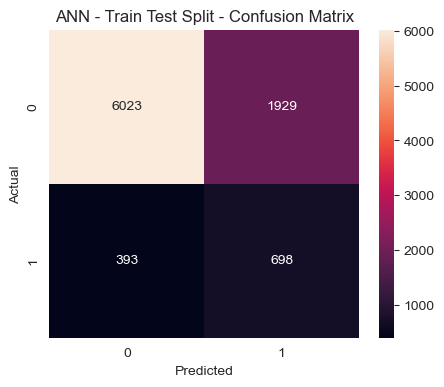

In [79]:
#loading the classifier
rf_clf = RandomForestClassifier(random_state=42)

# Define hyperparameter grids for Randomized Search and Grid Search
param_grid_random = {
    'n_estimators': [int(x) for x in np.linspace(start=200, stop=2000, num=10)],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [int(x) for x in np.linspace(10, 110, num=11)] + [None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Random Search
rand_search = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_grid_random, 
                                   n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
rand_search.fit(x_train_sm, y_train_sm)

# Print the best hyperparameters found by each search method
print("Random Search - Best Hyperparameters: ")
print(rand_search.best_params_)

y_rand_pred = rand_search.predict(X_test)
print('\n clasification report:\n', classification_report(y_test,y_rand_pred))
print("\n")

conf_mat = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN - Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Applying RandomSearchCV on Undersampled Train Test Split

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Random Search - Best Hyperparameters: 
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'auto', 'max_depth': 10, 'bootstrap': True}

 clasification report:
               precision    recall  f1-score   support

           0       0.94      0.76      0.84      7952
           1       0.27      0.63      0.38      1091

    accuracy                           0.75      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.75      0.79      9043





Text(35.22222222222222, 0.5, 'Actual')

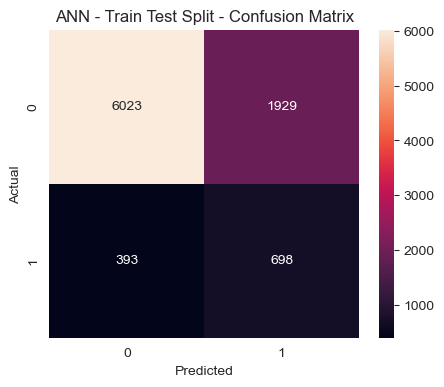

In [82]:
#loading the classifier
rf_clf = RandomForestClassifier(random_state=42)

# Define hyperparameter grids for Randomized Search and Grid Search
param_grid_random = {
    'n_estimators': [int(x) for x in np.linspace(start=200, stop=2000, num=10)],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [int(x) for x in np.linspace(10, 110, num=11)] + [None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Random Search
rand_search = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_grid_random, 
                                   n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
rand_search.fit(x_train_uns, y_train_uns)

# Print the best hyperparameters found by each search method
print("Random Search - Best Hyperparameters: ")
print(rand_search.best_params_)

y_rand_pred = rand_search.predict(X_test)
print('\n clasification report:\n', classification_report(y_test,y_rand_pred))
print("\n")

conf_mat = confusion_matrix(y_test,y_pred)
plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('ANN - Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## RF - Model Tuning of Max_depth and n_estimators (RandomSearchCV)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Random Search - Best Hyperparameters: 
{'bootstrap': True, 'max_depth': 9, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 91}

 clasification report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.72      0.17      0.28      1091

    accuracy                           0.89      9043
   macro avg       0.81      0.58      0.61      9043
weighted avg       0.88      0.89      0.86      9043



Text(35.22222222222222, 0.5, 'Actual')

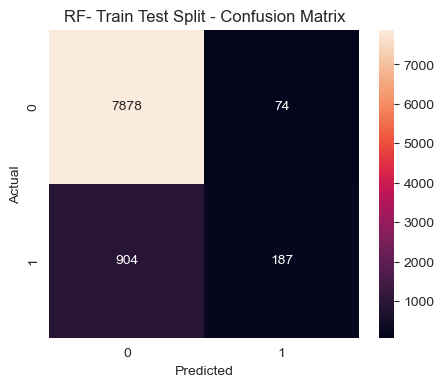

In [85]:
#Loading the Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)

# Define hyperparameter grids for Randomized Search
param_grid_random = {
    'n_estimators': randint(50,500),
    'max_features': ['auto', 'sqrt'],
    'max_depth': randint(1,20) , 
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Random Search
rand_search = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_grid_random, n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
rand_search.fit(X_train, y_train)

# Print the best hyperparameters found by each search method
print("Random Search - Best Hyperparameters: ")
print(rand_search.best_params_)

y_rand_pred = rand_search.predict(X_test)
print('\n clasification report:\n', classification_report(y_test,y_rand_pred))

conf_mat = confusion_matrix(y_test,y_rand_pred)
plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('RF- Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Random Search - Best Hyperparameters: 
{'bootstrap': True, 'max_depth': 19, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 216}

 clasification report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91      7952
           1       0.38      0.43      0.40      1091

    accuracy                           0.85      9043
   macro avg       0.65      0.67      0.66      9043
weighted avg       0.86      0.85      0.85      9043



Text(35.22222222222222, 0.5, 'Actual')

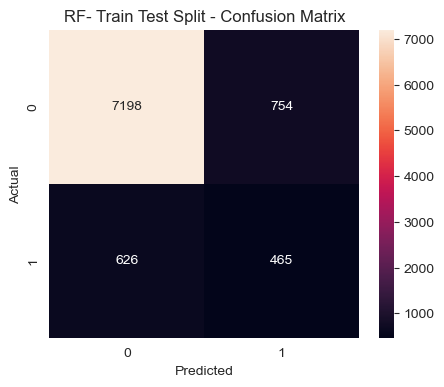

In [86]:
#Loading the Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)

# Define hyperparameter grids for Randomized Search
param_grid_random = {
    'n_estimators': randint(50,500),
    'max_features': ['auto', 'sqrt'],
    'max_depth': randint(1,20) , 
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Random Search
rand_search = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_grid_random, n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
rand_search.fit(x_train_sm, y_train_sm)

# Print the best hyperparameters found by each search method
print("Random Search - Best Hyperparameters: ")
print(rand_search.best_params_)

y_rand_pred = rand_search.predict(X_test)
print('\n clasification report:\n', classification_report(y_test,y_rand_pred))

conf_mat = confusion_matrix(y_test,y_rand_pred)
plt.figure(figsize = (5,4))
sb.heatmap(conf_mat, annot=True, fmt='d')
plt.title('RF- Train Test Split - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


# Evaluation of the Models

## Feature Importance for RF - Chosen Model

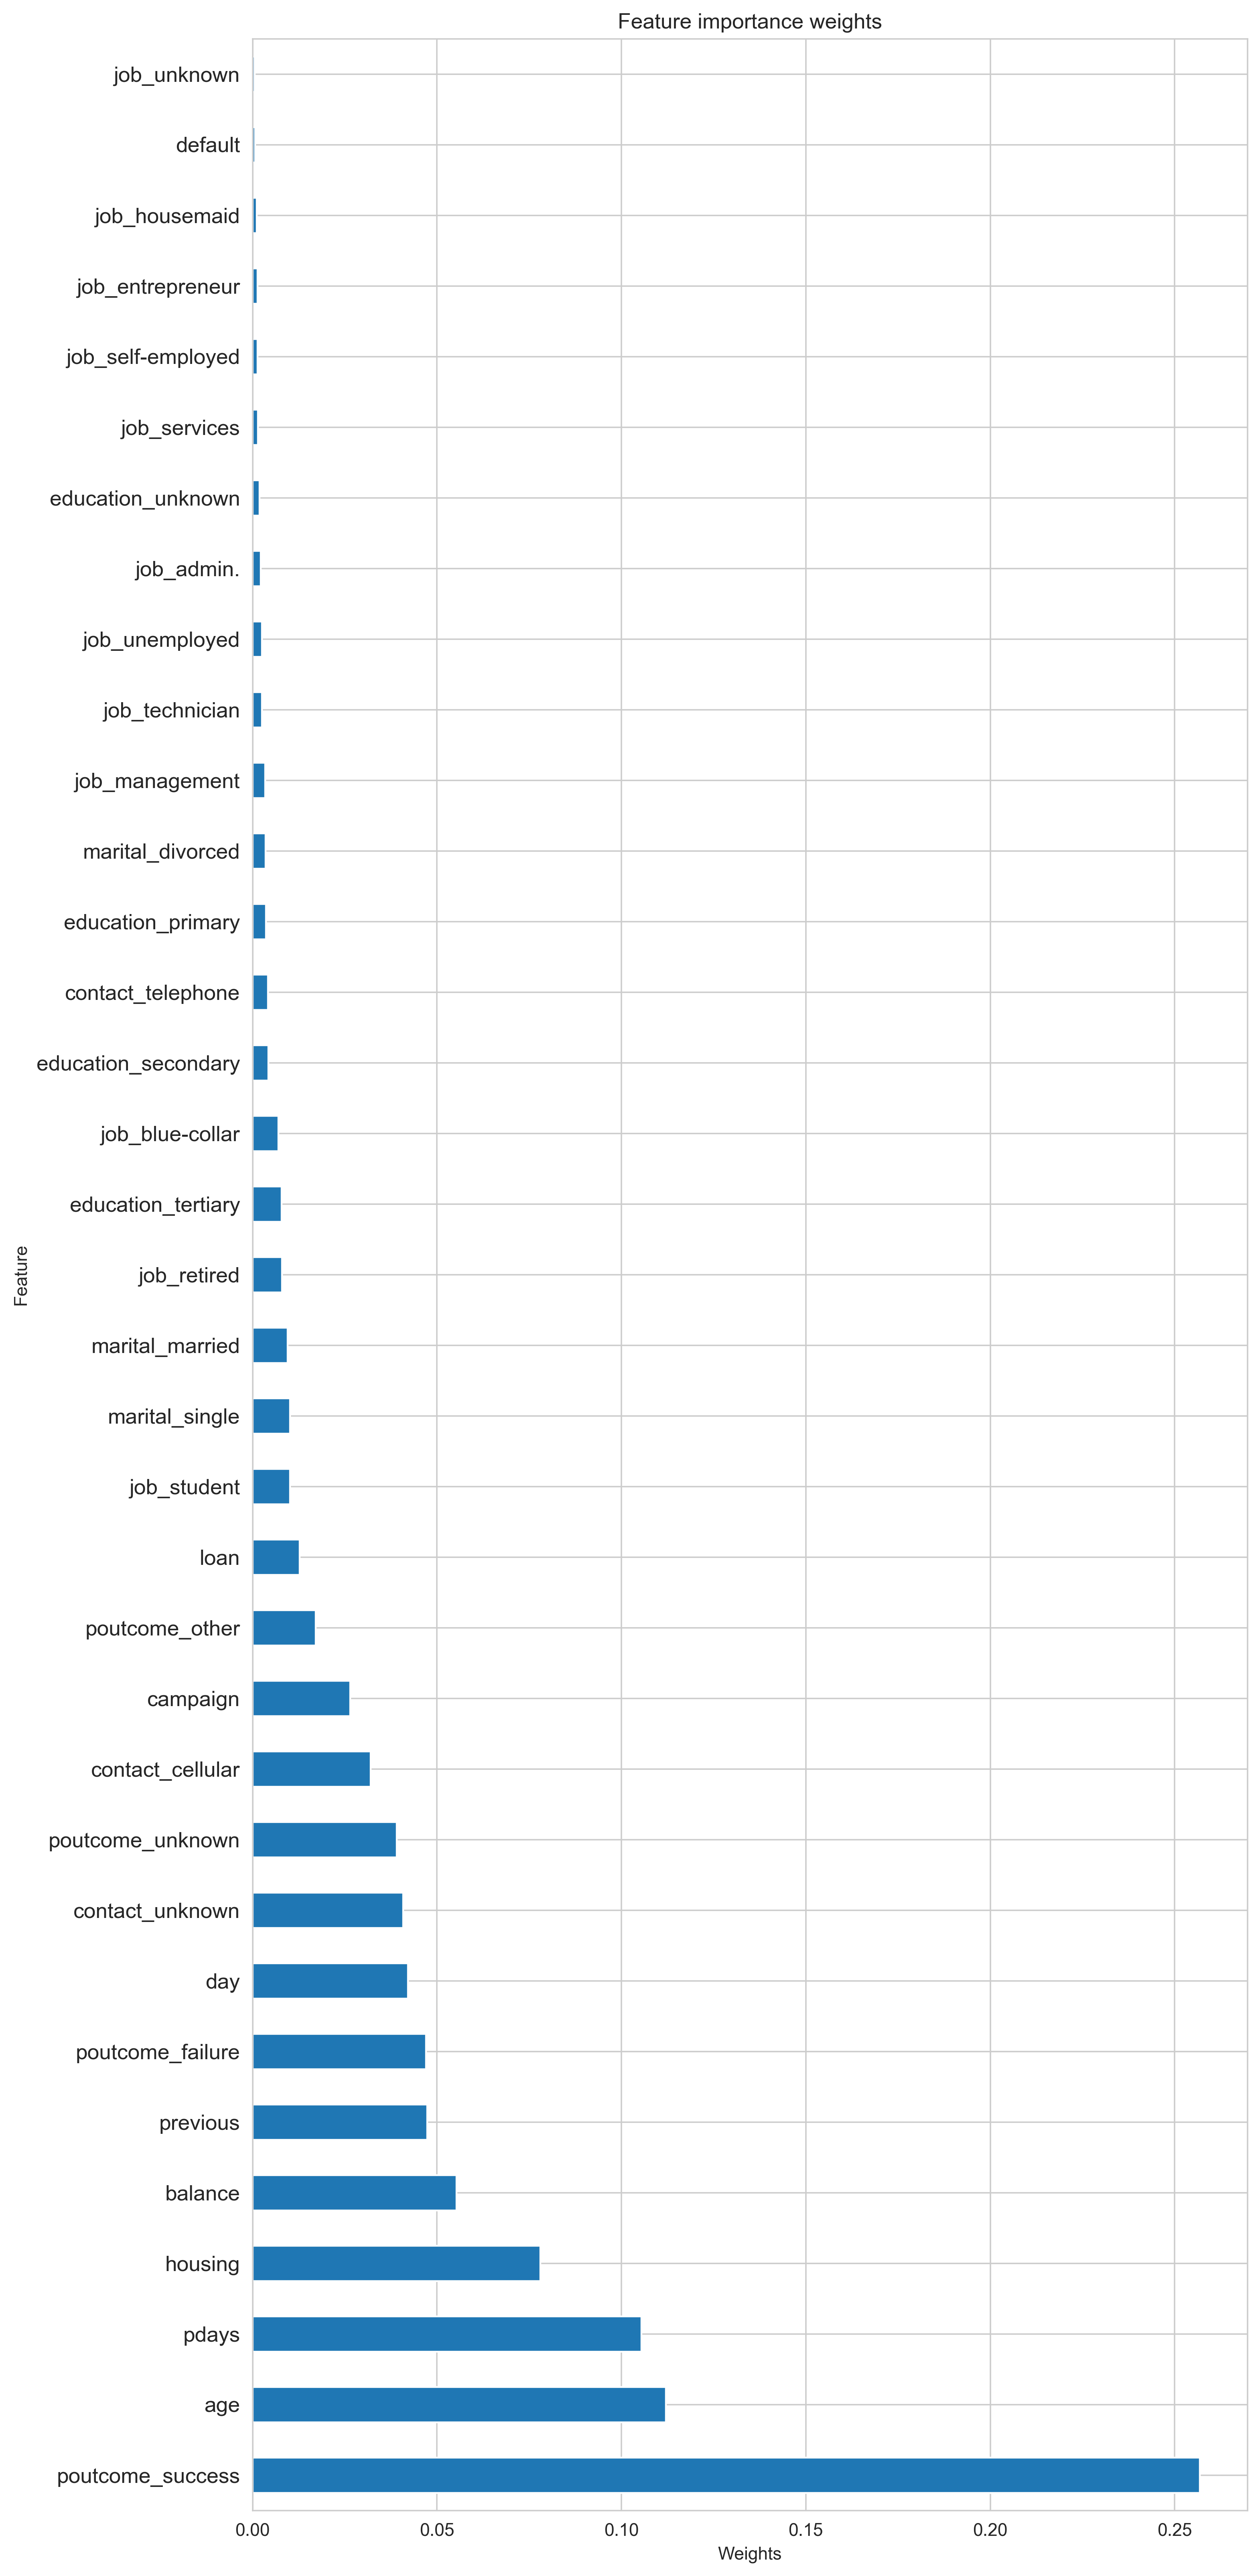

In [47]:
rf_clf = RandomForestClassifier(n_estimators=91, max_depth = 9, max_features="auto",random_state=0, min_samples_leaf = 4, min_samples_split = 5, bootstrap = True )
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

plt.figure(num=None, figsize=(10,25), dpi=320, facecolor='w', edgecolor='k')

feat_importances = pd.Series(rf_clf.feature_importances_, index= X_train.columns)
feat_importances.nlargest(180).plot(kind='barh')
plt.title('Feature importance weights')
plt.xlabel('Weights')
plt.ylabel('Feature')
plt.yticks(fontsize = 12)
plt.show();

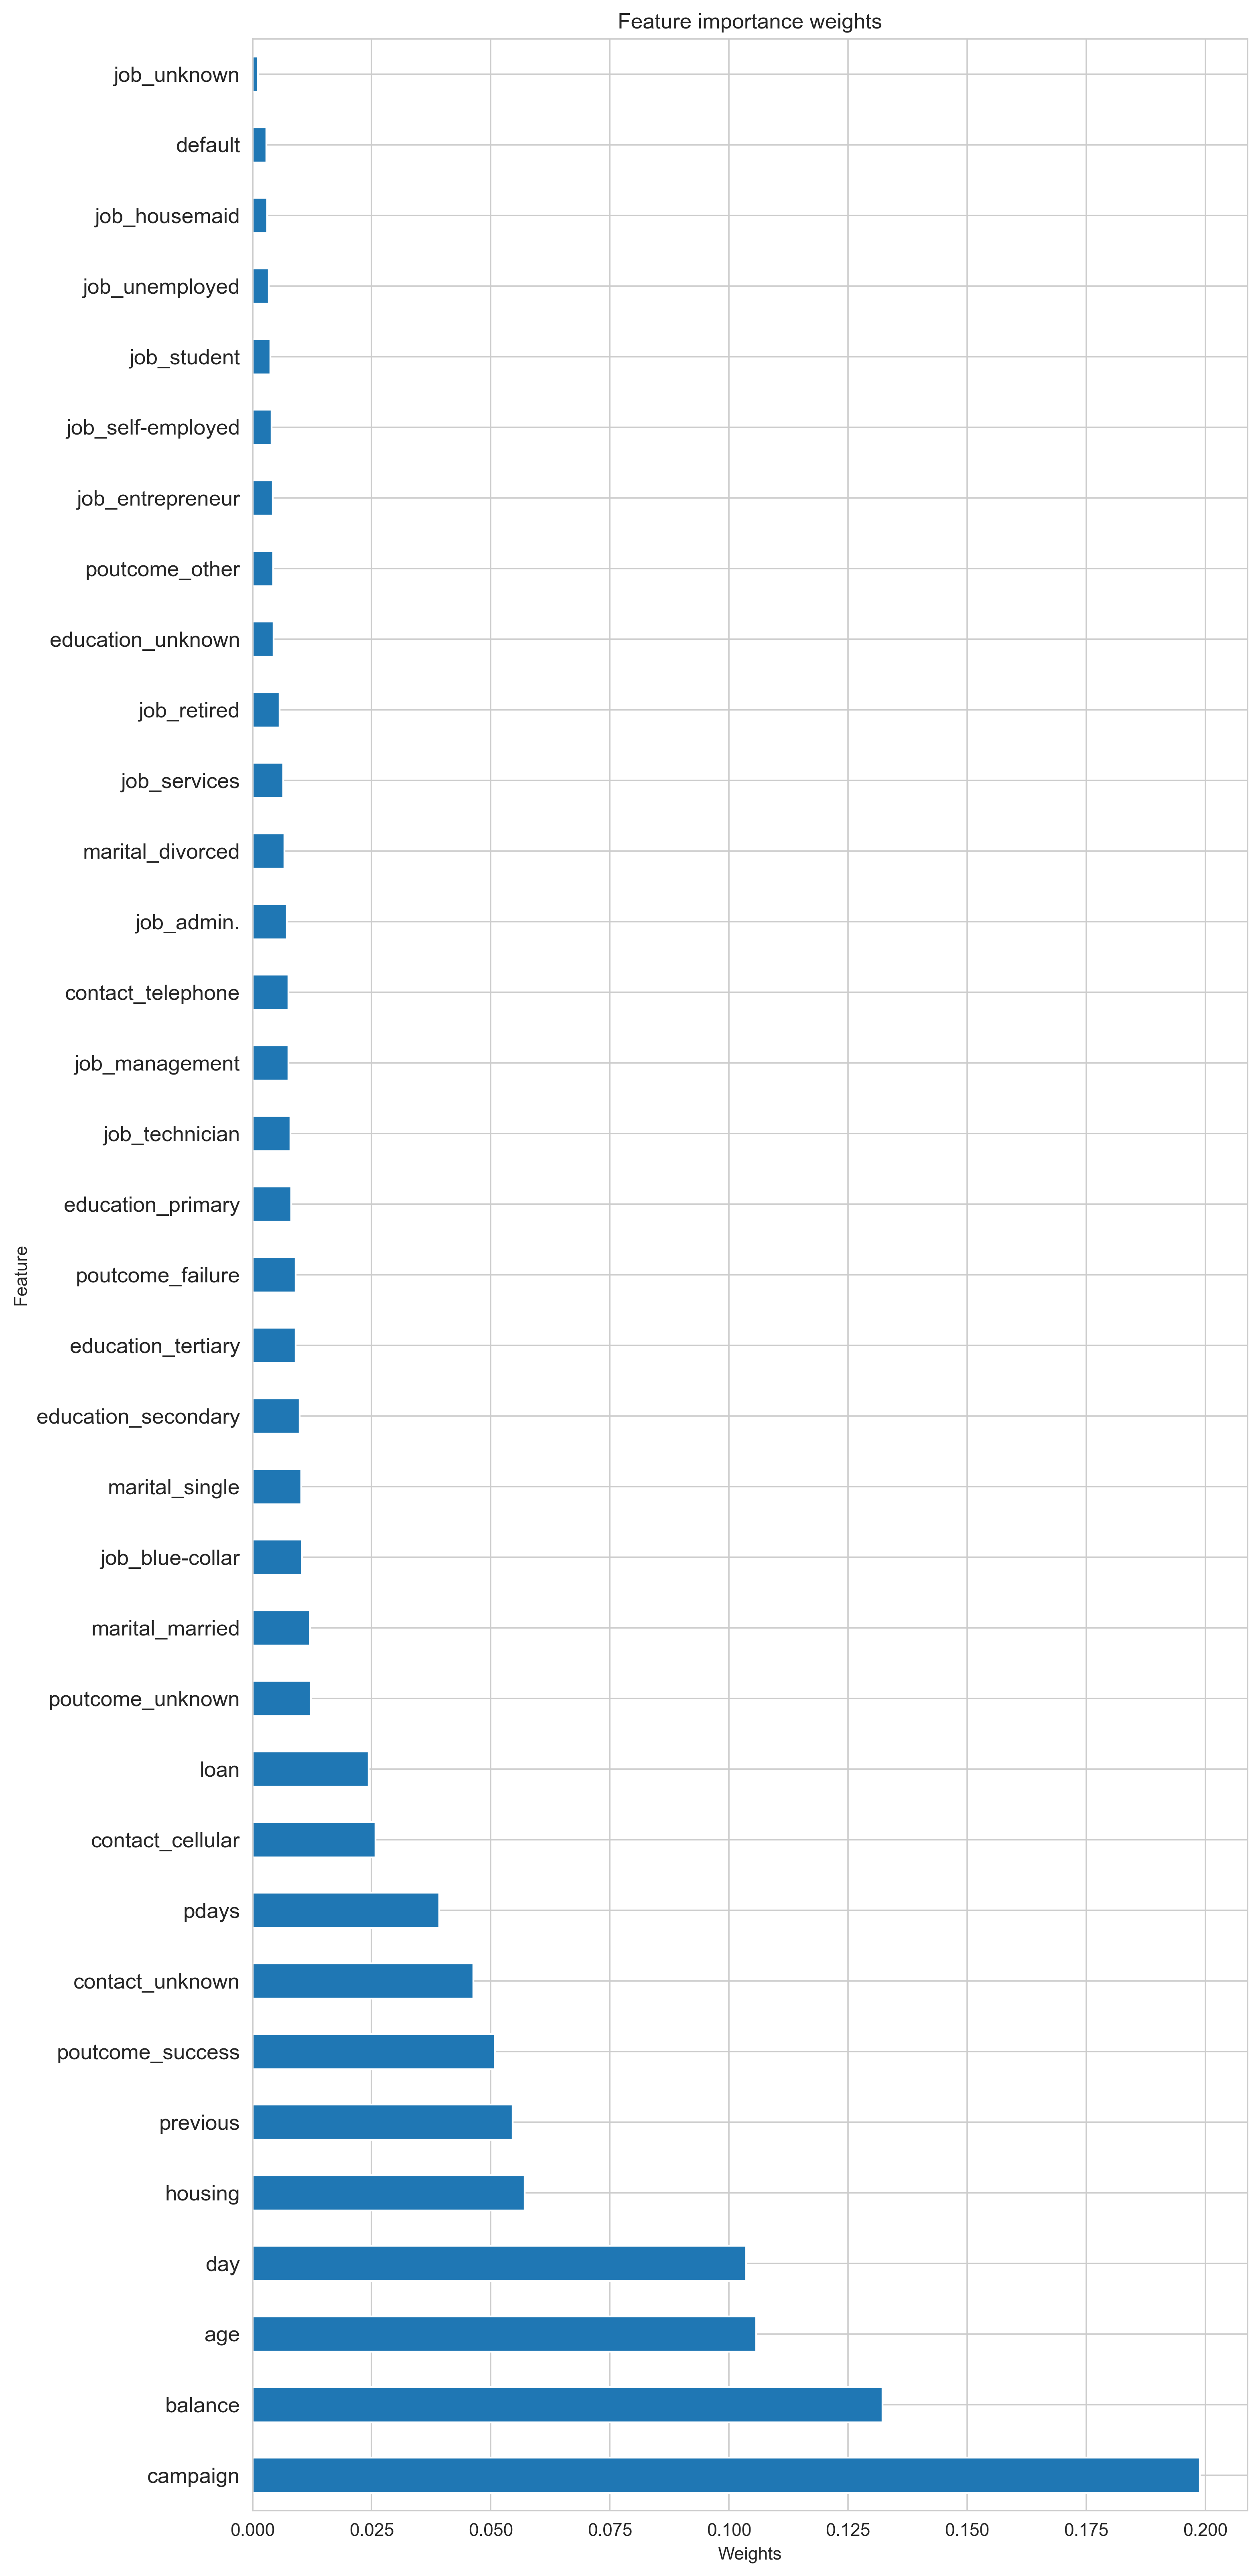

In [48]:
rf_clf = RandomForestClassifier(n_estimators=216, max_depth = 19, random_state=0, min_samples_leaf = 1, min_samples_split = 2, bootstrap = True, max_features ="auto" )
rf_clf.fit(x_train_sm, y_train_sm)
y_pred = rf_clf.predict(X_test)

plt.figure(num=None, figsize=(10,25), dpi=320, facecolor='w', edgecolor='k')

feat_importances = pd.Series(rf_clf.feature_importances_, index= x_train_sm.columns)
feat_importances.nlargest(180).plot(kind='barh')
plt.title('Feature importance weights')
plt.xlabel('Weights')
plt.ylabel('Feature')
plt.yticks(fontsize = 12)
plt.show();

# SVM Non-Tuned

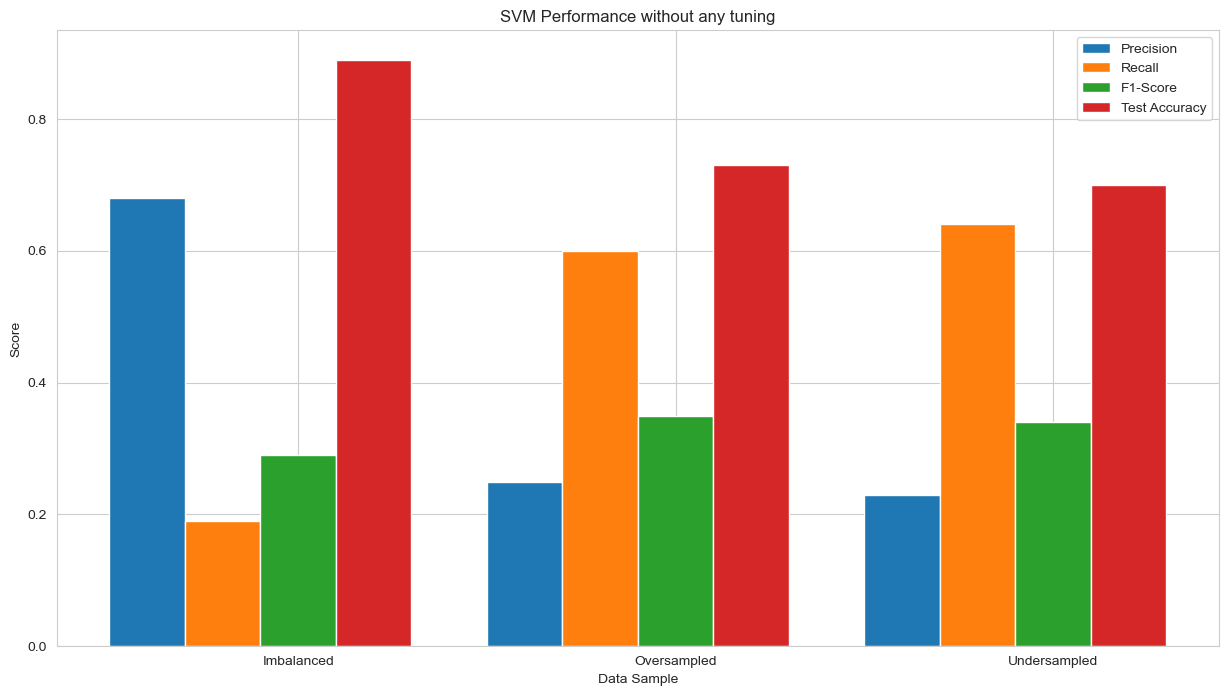

In [120]:
x = ['Imbalanced','Oversampled','Undersampled']
prec = [0.68, 0.25, 0.23]
rec = [0.19, 0.60, 0.64]
f1_sc = [0.29, 0.35, 0.34]
test_acc = [0.89, 0.73, 0.70]

x_axis = np.arange(len(x))
width = 0.2
plt.figure(figsize=(15,8))
plt.bar(x_axis - 2 * width, prec, width, label='Precision')
plt.bar(x_axis - width, rec, width, label='Recall')
plt.bar(x_axis, f1_sc, width, label='F1-Score')
plt.bar(x_axis + width, test_acc, width, label='Test Accuracy')

plt.xticks(x_axis, x)
plt.xlabel('Data Sample')
plt.ylabel('Score')
plt.title('SVM Performance without any tuning')
plt.legend()
plt.show()


## SVM with hyper-parameter tuning using GridSearchCV

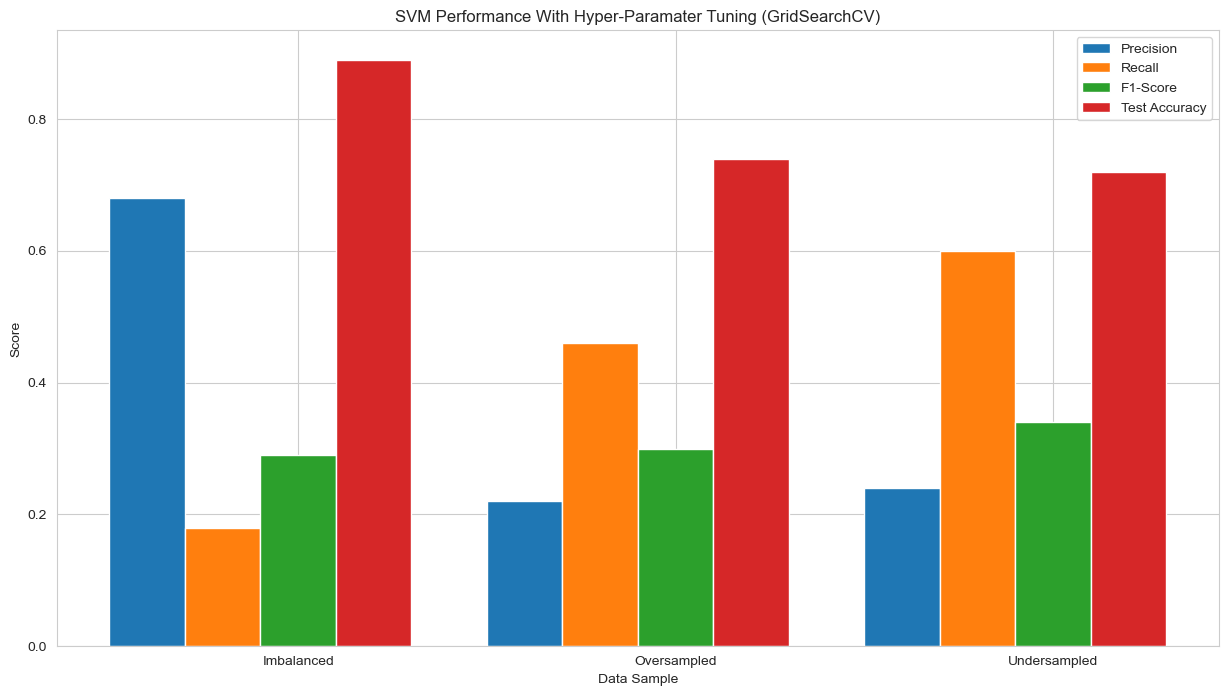

In [119]:
x = ['Imbalanced','Oversampled','Undersampled']
prec = [0.68, 0.22, 0.24]
rec = [0.18, 0.46, 0.60]
f1_sc = [0.29, 0.30, 0.34]
test_acc = [0.89, 0.74, 0.72]

x_axis = np.arange(len(x))
width = 0.2
plt.figure(figsize=(15,8))
plt.bar(x_axis - 2 * width, prec, width, label='Precision')
plt.bar(x_axis - width, rec, width, label='Recall')
plt.bar(x_axis, f1_sc, width, label='F1-Score')
plt.bar(x_axis + width, test_acc, width, label='Test Accuracy')

plt.xticks(x_axis, x)
plt.xlabel('Data Sample')
plt.ylabel('Score')
plt.title('SVM Performance With Hyper-Paramater Tuning (GridSearchCV)')
plt.legend()
plt.show()


## ANN - Without Tuning

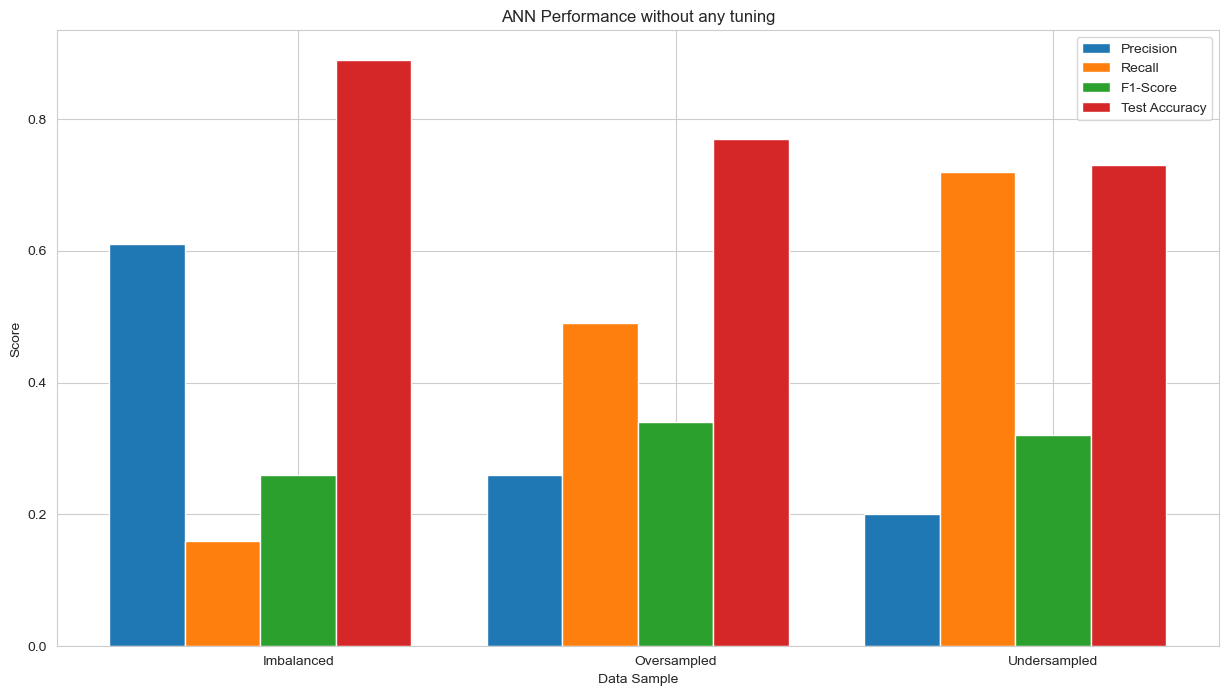

In [124]:
x = ['Imbalanced','Oversampled','Undersampled']
prec = [0.61, 0.26, 0.20]
rec = [0.16, 0.49, 0.72]
f1_sc = [0.26, 0.34, 0.32]
test_acc = [0.89, 0.77, 0.73]

x_axis = np.arange(len(x))
width = 0.2
plt.figure(figsize=(15,8))
plt.bar(x_axis - 2 * width, prec, width, label='Precision')
plt.bar(x_axis - width, rec, width, label='Recall')
plt.bar(x_axis, f1_sc, width, label='F1-Score')
plt.bar(x_axis + width, test_acc, width, label='Test Accuracy')

plt.xticks(x_axis, x)
plt.xlabel('Data Sample')
plt.ylabel('Score')
plt.title('ANN Performance without any tuning')
plt.legend()
plt.show()


## ANN - (Oversampled Set) With Hyper-Parameter Tuned Models

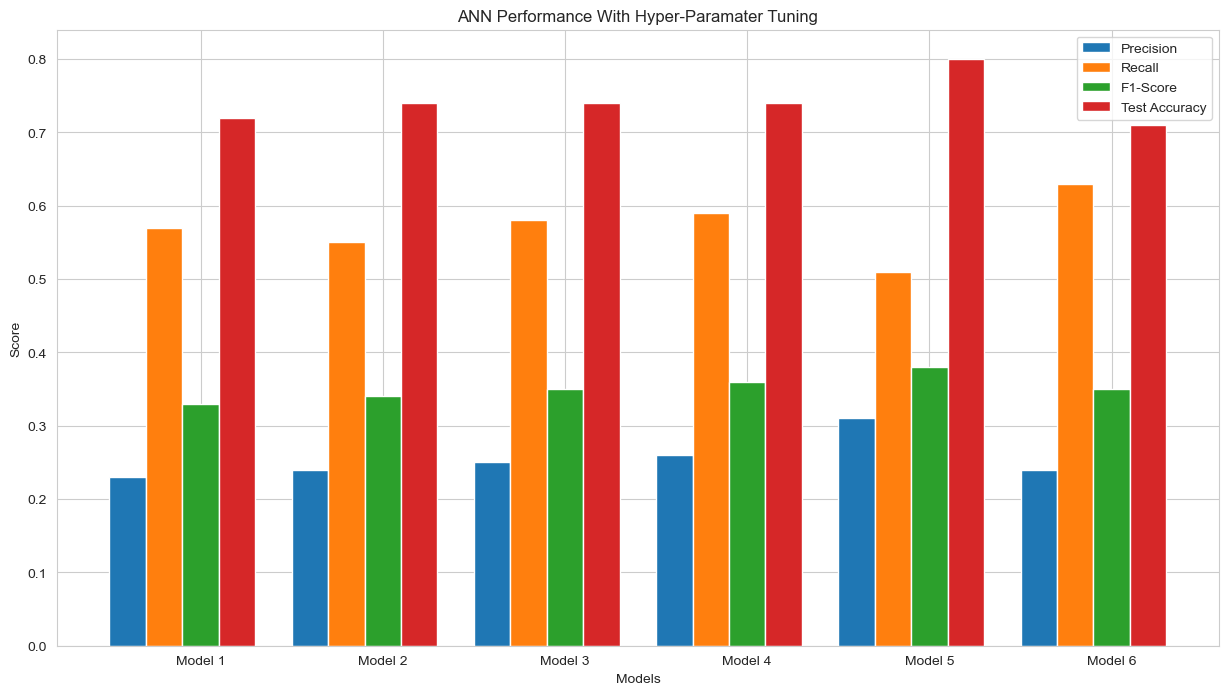

In [123]:
x = ['Model 1','Model 2','Model 3','Model 4','Model 5','Model 6']
prec = [0.23, 0.24, 0.25, 0.26, 0.31, 0.24]
rec = [0.57, 0.55, 0.58, 0.59, 0.51, 0.63]
f1_sc = [0.33, 0.34, 0.35, 0.36, 0.38, 0.35]
test_acc = [0.72, 0.74, 0.74, 0.74, 0.80, 0.71]

x_axis = np.arange(len(x))
width = 0.2
plt.figure(figsize=(15,8))
plt.bar(x_axis - 2 * width, prec, width, label='Precision')
plt.bar(x_axis - width, rec, width, label='Recall')
plt.bar(x_axis, f1_sc, width, label='F1-Score')
plt.bar(x_axis + width, test_acc, width, label='Test Accuracy')

plt.xticks(x_axis, x)
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('ANN Performance With Hyper-Paramater Tuning')
plt.legend()
plt.show()


# Random Forests - Without Tuning

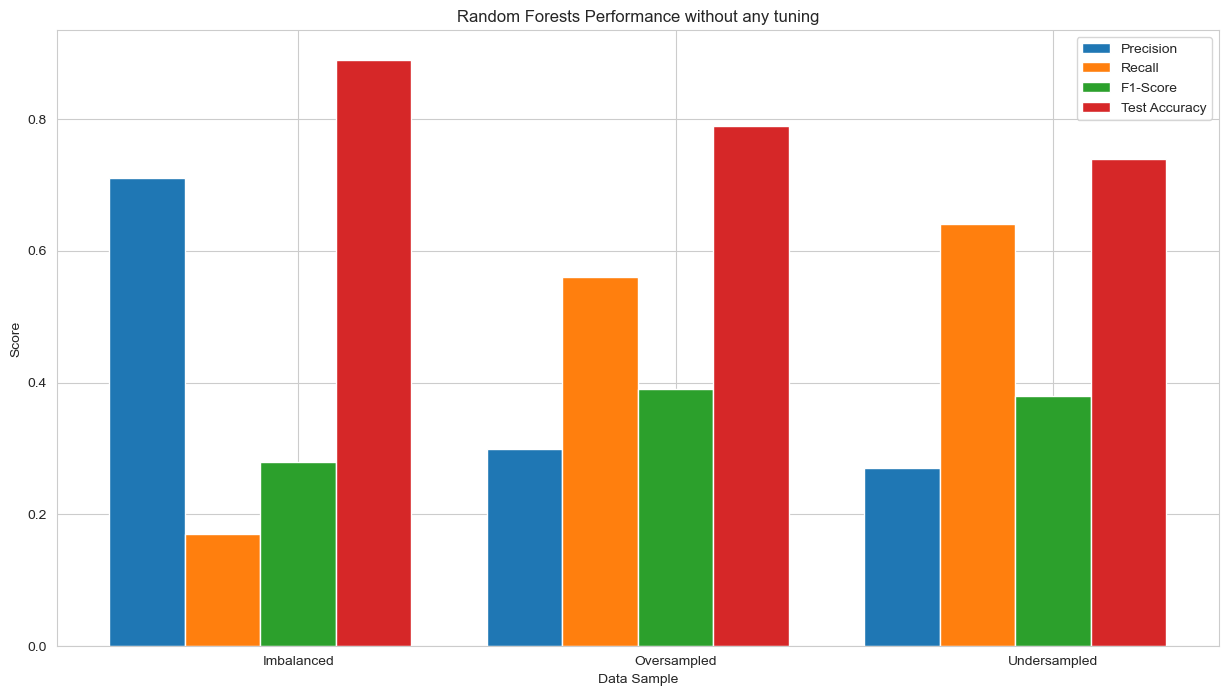

In [125]:
x = ['Imbalanced','Oversampled','Undersampled']
prec = [0.71, 0.30, 0.27]
rec = [0.17, 0.56, 0.64]
f1_sc = [0.28, 0.39, 0.38]
test_acc = [0.89, 0.79, 0.74]

x_axis = np.arange(len(x))
width = 0.2
plt.figure(figsize=(15,8))
plt.bar(x_axis - 2 * width, prec, width, label='Precision')
plt.bar(x_axis - width, rec, width, label='Recall')
plt.bar(x_axis, f1_sc, width, label='F1-Score')
plt.bar(x_axis + width, test_acc, width, label='Test Accuracy')

plt.xticks(x_axis, x)
plt.xlabel('Data Sample')
plt.ylabel('Score')
plt.title('Random Forests Performance without any tuning')
plt.legend()
plt.show()


# RF - With Hyper-Parameter Tuning (RandomSearchCV)

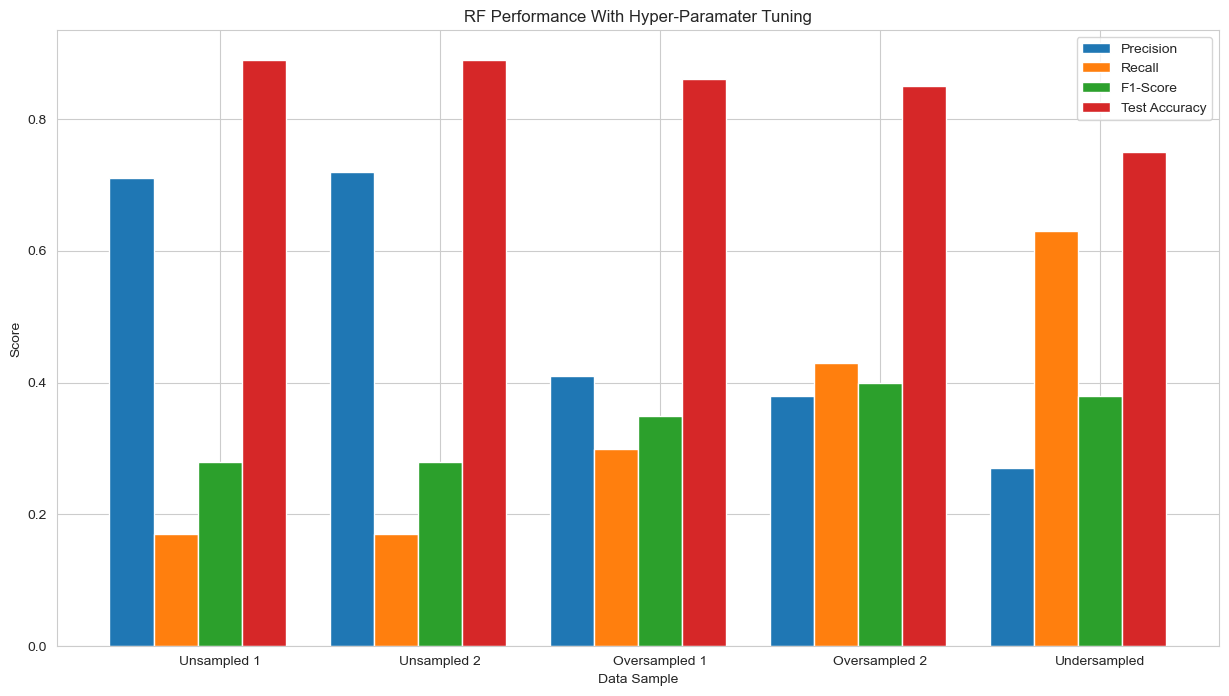

In [126]:
x = ['Unsampled 1','Unsampled 2','Oversampled 1','Oversampled 2','Undersampled']
prec = [0.71, 0.72, 0.41, 0.38, 0.27]
rec = [0.17, 0.17, 0.30, 0.43, 0.63]
f1_sc = [0.28, 0.28, 0.35, 0.40, 0.38]
test_acc = [0.89, 0.89, 0.86, 0.85, 0.75]

x_axis = np.arange(len(x))
width = 0.2
plt.figure(figsize=(15,8))
plt.bar(x_axis - 2 * width, prec, width, label='Precision')
plt.bar(x_axis - width, rec, width, label='Recall')
plt.bar(x_axis, f1_sc, width, label='F1-Score')
plt.bar(x_axis + width, test_acc, width, label='Test Accuracy')

plt.xticks(x_axis, x)
plt.xlabel('Data Sample')
plt.ylabel('Score')
plt.title('RF Performance With Hyper-Paramater Tuning')
plt.legend()
plt.show()


Note: Unsampled 2 and Oversampled 2 is the manipulated n_estimators and max_depth with the randint function while using RandomSearchCV

# Evaluation of the trained Models

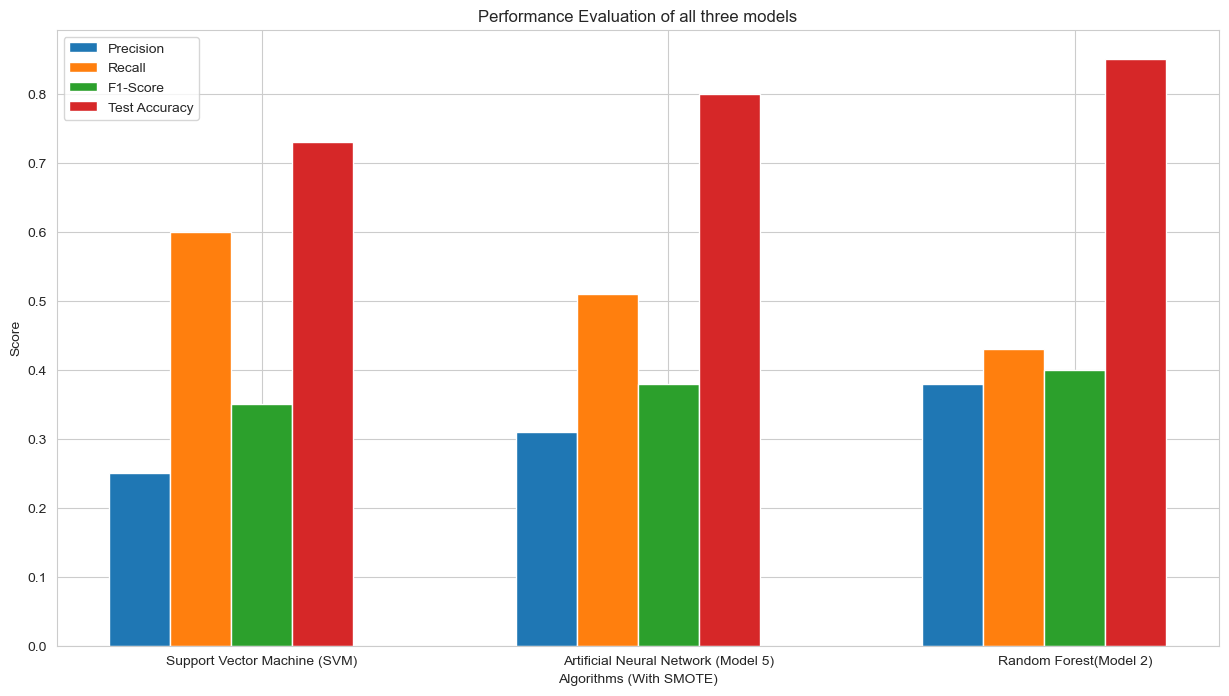

In [132]:
x = ['Support Vector Machine (SVM)','Artificial Neural Network (Model 5)','Random Forest(Model 2)']
prec = [0.25, 0.31, 0.38]
rec = [0.60, 0.51, 0.43]
f1_sc = [0.35, 0.38, 0.40]
test_acc = [0.73, 0.80, 0.85]

x_axis = np.arange(len(x))
width = 0.15
plt.figure(figsize=(15,8))
plt.bar(x_axis - 2 * width, prec, width, label='Precision')
plt.bar(x_axis - width, rec, width, label='Recall')
plt.bar(x_axis, f1_sc, width, label='F1-Score')
plt.bar(x_axis + width, test_acc, width, label='Test Accuracy')

plt.xticks(x_axis, x)
plt.xlabel('Algorithms (With SMOTE)')
plt.ylabel('Score')
plt.title('Performance Evaluation of all three models')
plt.legend()
plt.show()


# Saving the Chosen Model

In [129]:
#Using the Pickle Function to save model for later use.
pickle.dump(rf_clf, open('model.pkl', 'wb'))

In [52]:
model_columns = list(x.columns)
pickle.dump(model_columns, open('model_columns.pkl', 'wb'))

In [61]:
y_pred[150:180]

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [62]:
y_test[150:180]

13889    0
41149    1
35926    0
44709    0
36597    0
34204    0
30856    0
19633    0
42908    0
10688    0
17049    0
3617     0
29183    0
17099    0
23342    0
2624     0
40496    0
44501    1
12422    0
29253    0
43944    0
41528    1
17815    0
28326    0
39157    0
4519     0
30169    0
9920     0
30948    0
7070     0
Name: churn, dtype: int64